In [9]:
from pathlib import Path
import random
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.14.0+cpu


In [10]:
PROJECT_ROOT = Path(r"C:\Users\ADMIN\FinGraph-Sentinel")

INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "phase13"
    / "phase13_expanded_temporal_dataset.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "phase13_reproducible"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Input path:", INPUT_PATH)
print("Output directory:", OUTPUT_DIR)
print("Device:", DEVICE)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Expanded Phase 13 dataset was not found:\n{INPUT_PATH}"
    )

Project root: C:\Users\ADMIN\FinGraph-Sentinel
Input path: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_expanded_temporal_dataset.csv
Output directory: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible
Device: cpu


In [11]:
df = pd.read_csv(INPUT_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
for column in df.columns:
    print("-", column)

print("\nFirst five rows:")
display(df.head())

Dataset loaded successfully.
Shape: (1175, 23)

Columns:
- date
- nodes
- edges
- density
- average_degree
- average_strength
- average_clustering
- connected_components
- degree_concentration
- market_return
- market_volatility
- return_dispersion
- negative_fraction
- market_index
- running_peak
- drawdown
- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d
- future_volatility_event
- future_drawdown_event
- future_stress_event

First five rows:


,date,nodes,edges,density,average_degree,average_strength,average_clustering,connected_components,degree_concentration,market_return,...,market_index,running_peak,drawdown,future_return_20d,future_max_drawdown_20d,future_volatility_20d,future_negative_fraction_20d,future_volatility_event,future_drawdown_event,future_stress_event
0,2021-11-12 05:00:00,10,8,0.177778,1.6,1.004483,0.134435,5,1.280625,0.010352,...,1.010352,1.010352,0.000000,-0.012822,-0.038069,0.015409,0.50,False,False,0
1,2021-11-15 05:00:00,10,7,0.155556,1.4,0.903223,0.180070,5,1.200000,-0.001608,...,1.008727,1.010352,-0.001608,-0.018331,-0.036519,0.015477,0.50,False,False,0
2,2021-11-16 05:00:00,10,6,0.133333,1.2,0.797787,0.221044,6,1.166190,0.007416,...,1.016208,1.016208,0.000000,-0.003358,-0.043612,0.016229,0.50,False,False,0
3,2021-11-17 05:00:00,10,6,0.133333,1.2,0.795784,0.220136,6,1.166190,-0.006493,...,1.009609,1.016208,-0.006493,-0.017053,-0.037361,0.016764,0.50,False,False,0
4,2021-11-18 05:00:00,10,7,0.155556,1.4,0.911687,0.182034,5,1.200000,0.012402,...,1.022131,1.022131,0.000000,-0.037287,-0.049154,0.016563,0.55,False,False,0


In [12]:
TARGET_COLUMN = "future_stress_event"
DATE_COLUMN = "date"

required_columns = [DATE_COLUMN, TARGET_COLUMN]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}\n"
        f"Available columns: {list(df.columns)}"
    )

print("Required columns are available.")

Required columns are available.


In [13]:
TARGET_COLUMN = "future_stress_event"
DATE_COLUMN = "date"

required_columns = [DATE_COLUMN, TARGET_COLUMN]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}\n"
        f"Available columns: {list(df.columns)}"
    )

print("Required columns are available.")

Required columns are available.


In [14]:
def convert_target(value):
    if isinstance(value, bool):
        return int(value)

    if isinstance(value, (int, np.integer)):
        if value in [0, 1]:
            return int(value)

    if isinstance(value, (float, np.floating)):
        if value in [0.0, 1.0]:
            return int(value)

    text_value = str(value).strip().lower()

    if text_value in ["true", "1", "yes"]:
        return 1

    if text_value in ["false", "0", "no"]:
        return 0

    raise ValueError(f"Invalid target value: {value}")


df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(convert_target)

target_distribution = df[TARGET_COLUMN].value_counts().sort_index()

print("Target distribution:")
display(target_distribution)

if df[TARGET_COLUMN].nunique() < 2:
    raise ValueError(
        "The target contains only one class. "
        "Temporal classification cannot be trained."
    )

print("\nTarget event rate:")
print(df[TARGET_COLUMN].mean())

Target distribution:


future_stress_event
0    1027
1     148
Name: count, dtype: int64


Target event rate:
0.12595744680851065


In [15]:
numeric_columns_before = df.select_dtypes(
    include=[np.number]
).columns.tolist()

df[numeric_columns_before] = df[numeric_columns_before].replace(
    [np.inf, -np.inf],
    np.nan
)

nan_summary = df.isna().sum()
nan_summary = nan_summary[nan_summary > 0].sort_values(ascending=False)

print("Columns containing missing values:")
display(nan_summary)

if len(nan_summary) > 0:
    print(
        "\nMissing numeric values will be forward-filled "
        "using past observations only."
    )

    numeric_columns = df.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    numeric_columns_without_target = [
        column
        for column in numeric_columns
        if column != TARGET_COLUMN
    ]

    df[numeric_columns_without_target] = (
        df[numeric_columns_without_target]
        .ffill()
        .bfill()
    )

if df.isna().sum().sum() > 0:
    raise ValueError(
        "Missing values remain after cleaning. "
        "Inspect the dataset before proceeding."
    )

print("Invalid-value validation completed.")

Columns containing missing values:


Series([], dtype: int64)

Invalid-value validation completed.


In [16]:
all_numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

excluded_columns = {
    TARGET_COLUMN,
    "future_max_stress"
}

feature_columns = [
    column
    for column in all_numeric_columns
    if column not in excluded_columns
]

if len(feature_columns) == 0:
    raise ValueError(
        "No valid numeric feature columns were found."
    )

print("Selected feature columns:")
for column in feature_columns:
    print("-", column)

print("\nNumber of features:", len(feature_columns))

Selected feature columns:
- nodes
- edges
- density
- average_degree
- average_strength
- average_clustering
- connected_components
- degree_concentration
- market_return
- market_volatility
- return_dispersion
- negative_fraction
- market_index
- running_peak
- drawdown
- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d

Number of features: 19


In [17]:
correlation_data = df[feature_columns + [TARGET_COLUMN]].corr()

target_correlations = (
    correlation_data[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .abs()
    .sort_values(ascending=False)
)

print("Absolute feature correlations with the target:")
display(target_correlations)

Absolute feature correlations with the target:


future_volatility_20d           0.686050
future_max_drawdown_20d         0.625134
future_return_20d               0.446445
future_negative_fraction_20d    0.361024
drawdown                        0.317784
edges                           0.313684
density                         0.313684
average_degree                  0.313684
average_strength                0.302085
average_clustering              0.301495
connected_components            0.300694
market_index                    0.255564
running_peak                    0.205582
return_dispersion               0.069530
market_volatility               0.069530
market_return                   0.060794
degree_concentration            0.047684
negative_fraction               0.039327
nodes                                NaN
Name: future_stress_event, dtype: float64

In [18]:
total_rows = len(df)

train_end = int(total_rows * 0.60)
validation_end = int(total_rows * 0.80)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

print("Chronological split:")
print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Test rows:", len(test_df))

print("\nDate ranges:")
print(
    "Train:",
    train_df[DATE_COLUMN].min(),
    "to",
    train_df[DATE_COLUMN].max()
)

print(
    "Validation:",
    validation_df[DATE_COLUMN].min(),
    "to",
    validation_df[DATE_COLUMN].max()
)

print(
    "Test:",
    test_df[DATE_COLUMN].min(),
    "to",
    test_df[DATE_COLUMN].max()
)

print("\nTarget distributions:")
print("Train:")
display(train_df[TARGET_COLUMN].value_counts())

print("Validation:")
display(validation_df[TARGET_COLUMN].value_counts())

print("Test:")
display(test_df[TARGET_COLUMN].value_counts())

Chronological split:
Training rows: 705
Validation rows: 235
Test rows: 235

Date ranges:
Train: 2021-11-12 05:00:00 to 2024-09-04 04:00:00
Validation: 2024-09-05 04:00:00 to 2025-08-13 04:00:00
Test: 2025-08-14 04:00:00 to 2026-07-22 04:00:00

Target distributions:
Train:


future_stress_event
0    590
1    115
Name: count, dtype: int64

Validation:


future_stress_event
0    202
1     33
Name: count, dtype: int64

Test:


future_stress_event
0    235
Name: count, dtype: int64

In [19]:
scaler = StandardScaler()

scaler.fit(
    train_df[feature_columns]
)

train_features = scaler.transform(
    train_df[feature_columns]
)

validation_features = scaler.transform(
    validation_df[feature_columns]
)

test_features = scaler.transform(
    test_df[feature_columns]
)

train_targets = train_df[TARGET_COLUMN].to_numpy(dtype=np.float32)
validation_targets = validation_df[TARGET_COLUMN].to_numpy(dtype=np.float32)
test_targets = test_df[TARGET_COLUMN].to_numpy(dtype=np.float32)

print("Feature scaling completed.")
print("Training feature shape:", train_features.shape)
print("Validation feature shape:", validation_features.shape)
print("Test feature shape:", test_features.shape)

Feature scaling completed.
Training feature shape: (705, 19)
Validation feature shape: (235, 19)
Test feature shape: (235, 19)


In [20]:
SEQUENCE_LENGTH = 20


def create_sequences(features, targets, dates, sequence_length):
    X_sequences = []
    y_sequences = []
    sequence_dates = []

    if len(features) <= sequence_length:
        raise ValueError(
            "Not enough rows to create temporal sequences."
        )

    for end_index in range(
        sequence_length,
        len(features)
    ):
        start_index = end_index - sequence_length

        X_sequences.append(
            features[start_index:end_index]
        )

        y_sequences.append(
            targets[end_index]
        )

        sequence_dates.append(
            dates.iloc[end_index]
        )

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
        pd.Series(sequence_dates).reset_index(drop=True)
    )


X_train, y_train, dates_train = create_sequences(
    train_features,
    train_targets,
    train_df[DATE_COLUMN].reset_index(drop=True),
    SEQUENCE_LENGTH
)

X_validation, y_validation, dates_validation = create_sequences(
    validation_features,
    validation_targets,
    validation_df[DATE_COLUMN].reset_index(drop=True),
    SEQUENCE_LENGTH
)

X_test, y_test, dates_test = create_sequences(
    test_features,
    test_targets,
    test_df[DATE_COLUMN].reset_index(drop=True),
    SEQUENCE_LENGTH
)

print("Sequence shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Sequence shapes:
X_train: (685, 20, 19)
y_train: (685,)
X_validation: (215, 20, 19)
y_validation: (215,)
X_test: (215, 20, 19)
y_test: (215,)


In [21]:
def print_sequence_distribution(name, targets):
    targets_integer = targets.astype(int)

    print(f"\n{name}")
    print("Total sequences:", len(targets_integer))
    print("Normal samples:", int((targets_integer == 0).sum()))
    print("Stress samples:", int((targets_integer == 1).sum()))

    if len(targets_integer) > 0:
        print("Stress rate:", float(targets_integer.mean()))


print_sequence_distribution("Training", y_train)
print_sequence_distribution("Validation", y_validation)
print_sequence_distribution("Test", y_test)

if y_train.sum() == 0:
    raise ValueError(
        "Training sequences contain no positive stress events."
    )


Training
Total sequences: 685
Normal samples: 570
Stress samples: 115
Stress rate: 0.1678832116788321

Validation
Total sequences: 215
Normal samples: 182
Stress samples: 33
Stress rate: 0.15348837209302327

Test
Total sequences: 215
Normal samples: 215
Stress samples: 0
Stress rate: 0.0


In [22]:
class TemporalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = TemporalDataset(X_train, y_train)
validation_dataset = TemporalDataset(X_validation, y_validation)
test_dataset = TemporalDataset(X_test, y_test)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("PyTorch datasets and loaders created.")

PyTorch datasets and loaders created.


In [23]:
class TemporalGRU(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=32,
        num_layers=1,
        dropout=0.0
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        output, hidden = self.gru(x)

        final_output = output[:, -1, :]

        logits = self.classifier(
            final_output
        ).squeeze(-1)

        return logits


INPUT_SIZE = X_train.shape[2]

model = TemporalGRU(
    input_size=INPUT_SIZE,
    hidden_size=32,
    num_layers=1
).to(DEVICE)

print(model)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\nTrainable parameters:", parameter_count)

TemporalGRU(
  (gru): GRU(19, 32, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

Trainable parameters: 5633


In [24]:
positive_count = float((y_train == 1).sum())
negative_count = float((y_train == 0).sum())

if positive_count == 0:
    raise ValueError(
        "Cannot calculate class weight because "
        "there are no positive training samples."
    )

positive_weight = negative_count / positive_count

pos_weight_tensor = torch.tensor(
    [positive_weight],
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

print("Positive class weight:", positive_weight)
print("Loss function:", criterion)
print("Optimizer:", optimizer)

Positive class weight: 4.956521739130435
Loss function: BCEWithLogitsLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)


In [25]:
def collect_predictions(model, data_loader):
    model.eval()

    all_logits = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(DEVICE)

            logits = model(batch_X)

            all_logits.extend(
                logits.detach().cpu().numpy()
            )

            all_targets.extend(
                batch_y.numpy()
            )

    logits_array = np.asarray(all_logits)
    targets_array = np.asarray(all_targets).astype(int)

    probabilities = 1.0 / (
        1.0 + np.exp(-np.clip(logits_array, -50, 50))
    )

    return targets_array, probabilities


def calculate_metrics(targets, probabilities, threshold=0.5):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(
            targets,
            predictions
        ),
        "precision": precision_score(
            targets,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            targets,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            targets,
            predictions,
            zero_division=0
        ),
        "brier_score": brier_score_loss(
            targets,
            probabilities
        )
    }

    if len(np.unique(targets)) == 2:
        metrics["roc_auc"] = roc_auc_score(
            targets,
            probabilities
        )

        metrics["pr_auc"] = average_precision_score(
            targets,
            probabilities
        )
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics

In [26]:
MAX_EPOCHS = 100
PATIENCE = 12

best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

best_model_state = None

training_history = []

for epoch in range(1, MAX_EPOCHS + 1):

    model.train()

    training_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(batch_X)

        loss = criterion(
            logits,
            batch_y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        training_losses.append(
            loss.item()
        )

    train_loss = float(
        np.mean(training_losses)
    )

    model.eval()

    validation_losses = []

    with torch.no_grad():
        for batch_X, batch_y in validation_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            logits = model(batch_X)

            validation_loss = criterion(
                logits,
                batch_y
            )

            validation_losses.append(
                validation_loss.item()
            )

    val_loss = float(
        np.mean(validation_losses)
    )

    training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": val_loss
        }
    )

    if val_loss < best_validation_loss:
        best_validation_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train loss: {train_loss:.6f} | "
            f"Validation loss: {val_loss:.6f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}."
        )
        break

if best_model_state is None:
    raise RuntimeError(
        "No valid model checkpoint was created."
    )

model.load_state_dict(best_model_state)

history_df = pd.DataFrame(training_history)

history_path = (
    OUTPUT_DIR
    / "phase13_gru_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_validation_loss)
print("History saved to:", history_path)

Epoch 001 | Train loss: 1.114984 | Validation loss: 1.018971
Epoch 010 | Train loss: 0.380787 | Validation loss: 0.248495
Epoch 020 | Train loss: 0.289806 | Validation loss: 0.451561

Early stopping at epoch 21.

Training completed.
Best epoch: 9
Best validation loss: 0.24746629755411828
History saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_training_history.csv


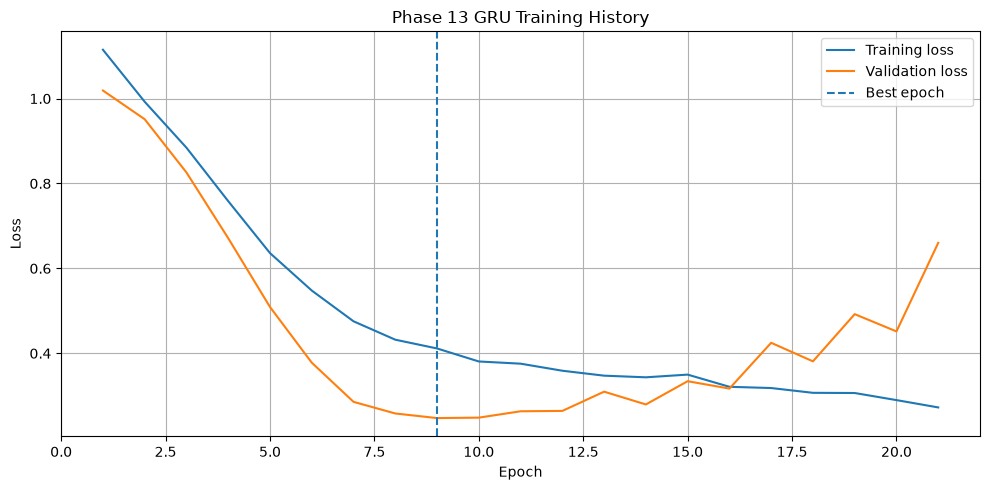

Plot saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_training_history.png


In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label="Best epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 13 GRU Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = (
    OUTPUT_DIR
    / "phase13_gru_training_history.png"
)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved to:", loss_plot_path)

In [28]:
validation_actuals, validation_probabilities = (
    collect_predictions(
        model,
        validation_loader
    )
)

validation_predictions_df = pd.DataFrame(
    {
        "date": dates_validation,
        "actual": validation_actuals,
        "probability": validation_probabilities
    }
)

validation_predictions_df["prediction"] = (
    validation_predictions_df["probability"] >= 0.5
).astype(int)

validation_predictions_df["correct"] = (
    validation_predictions_df["actual"]
    ==
    validation_predictions_df["prediction"]
)

validation_predictions_path = (
    OUTPUT_DIR
    / "phase13_gru_validation_predictions.csv"
)

validation_predictions_df.to_csv(
    validation_predictions_path,
    index=False
)

print("Validation predictions saved.")
display(validation_predictions_df.head())

Validation predictions saved.


,date,actual,probability,prediction,correct
0,2024-10-03 04:00:00,0,0.008002,0,True
1,2024-10-04 04:00:00,0,0.008183,0,True
2,2024-10-07 04:00:00,0,0.008684,0,True
3,2024-10-08 04:00:00,0,0.008311,0,True
4,2024-10-09 04:00:00,0,0.008306,0,True


In [29]:
validation_metrics = calculate_metrics(
    validation_actuals,
    validation_probabilities,
    threshold=0.5
)

validation_metrics_df = pd.DataFrame(
    [validation_metrics]
)

print("Validation metrics:")
display(validation_metrics_df)

validation_metrics_path = (
    OUTPUT_DIR
    / "phase13_gru_validation_metrics.csv"
)

validation_metrics_df.to_csv(
    validation_metrics_path,
    index=False
)

Validation metrics:


,threshold,accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc
0,0.5,0.953488,0.767442,1.0,0.868421,0.032975,0.993673,0.970447


In [30]:
threshold_results = []

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

for threshold in thresholds:
    metrics = calculate_metrics(
        validation_actuals,
        validation_probabilities,
        threshold=float(threshold)
    )

    threshold_results.append(metrics)

threshold_results_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

BEST_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print("Best validation threshold:", BEST_THRESHOLD)
print("\nMetrics at selected threshold:")
display(
    best_threshold_row.to_frame().T
)

threshold_results_path = (
    OUTPUT_DIR
    / "phase13_gru_validation_thresholds.csv"
)

threshold_results_df.to_csv(
    threshold_results_path,
    index=False
)

Best validation threshold: 0.7500000000000002

Metrics at selected threshold:


,threshold,accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc
70,0.75,0.972093,1.0,0.818182,0.9,0.032975,0.993673,0.970447


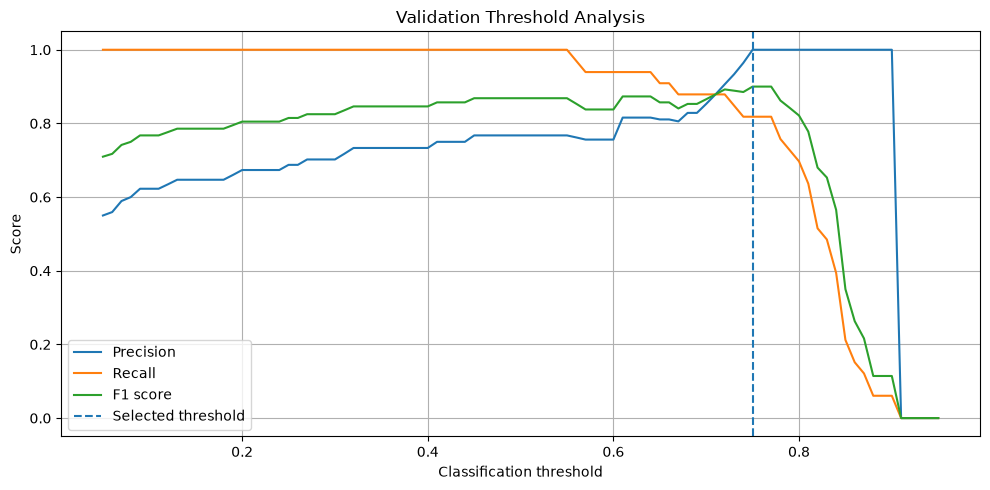

Threshold plot saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_threshold_analysis.png


In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    label="F1 score"
)

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label="Selected threshold"
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()

threshold_plot_path = (
    OUTPUT_DIR
    / "phase13_gru_threshold_analysis.png"
)

plt.savefig(
    threshold_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Threshold plot saved to:", threshold_plot_path)

In [32]:
test_actuals, test_probabilities = (
    collect_predictions(
        model,
        test_loader
    )
)

test_predictions = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

test_predictions_df = pd.DataFrame(
    {
        "date": dates_test,
        "actual": test_actuals,
        "probability": test_probabilities,
        "prediction": test_predictions
    }
)

test_predictions_df["correct"] = (
    test_predictions_df["actual"]
    ==
    test_predictions_df["prediction"]
)

test_predictions_path = (
    OUTPUT_DIR
    / "phase13_gru_test_predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)

print("Test predictions saved.")
display(test_predictions_df.head())

Test predictions saved.


,date,actual,probability,prediction,correct
0,2025-09-12 04:00:00,0,0.014755,0,True
1,2025-09-15 04:00:00,0,0.020473,0,True
2,2025-09-16 04:00:00,0,0.024431,0,True
3,2025-09-17 04:00:00,0,0.029289,0,True
4,2025-09-18 04:00:00,0,0.032422,0,True


In [33]:
test_metrics = calculate_metrics(
    test_actuals,
    test_probabilities,
    threshold=BEST_THRESHOLD
)

test_metrics["best_validation_threshold"] = BEST_THRESHOLD
test_metrics["best_epoch"] = best_epoch
test_metrics["sequence_length"] = SEQUENCE_LENGTH
test_metrics["input_feature_count"] = INPUT_SIZE
test_metrics["positive_class_weight"] = positive_weight

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

print("Final test metrics:")
display(test_metrics_df)

test_metrics_path = (
    OUTPUT_DIR
    / "phase13_gru_test_metrics.csv"
)

test_metrics_df.to_csv(
    test_metrics_path,
    index=False
)

Final test metrics:


,threshold,accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc,best_validation_threshold,best_epoch,sequence_length,input_feature_count,positive_class_weight
0,0.75,1.0,0.0,0.0,0.0,0.013981,NaN,NaN,0.75,9,20,19,4.956522


In [34]:
print("Classification report:")
print(
    classification_report(
        test_actuals,
        test_predictions,
        labels=[0, 1],
        target_names=["Normal", "Stress"],
        zero_division=0
    )
)

confusion_matrix_values = confusion_matrix(
    test_actuals,
    test_predictions,
    labels=[0, 1]
)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix_values,
    index=["Actual Normal", "Actual Stress"],
    columns=["Predicted Normal", "Predicted Stress"]
)

print("Confusion matrix:")
display(confusion_matrix_df)

confusion_matrix_path = (
    OUTPUT_DIR
    / "phase13_gru_confusion_matrix.csv"
)

confusion_matrix_df.to_csv(
    confusion_matrix_path
)

Classification report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       215
      Stress       0.00      0.00      0.00         0

    accuracy                           1.00       215
   macro avg       0.50      0.50      0.50       215
weighted avg       1.00      1.00      1.00       215

Confusion matrix:


,Predicted Normal,Predicted Stress
Actual Normal,215,0
Actual Stress,0,0


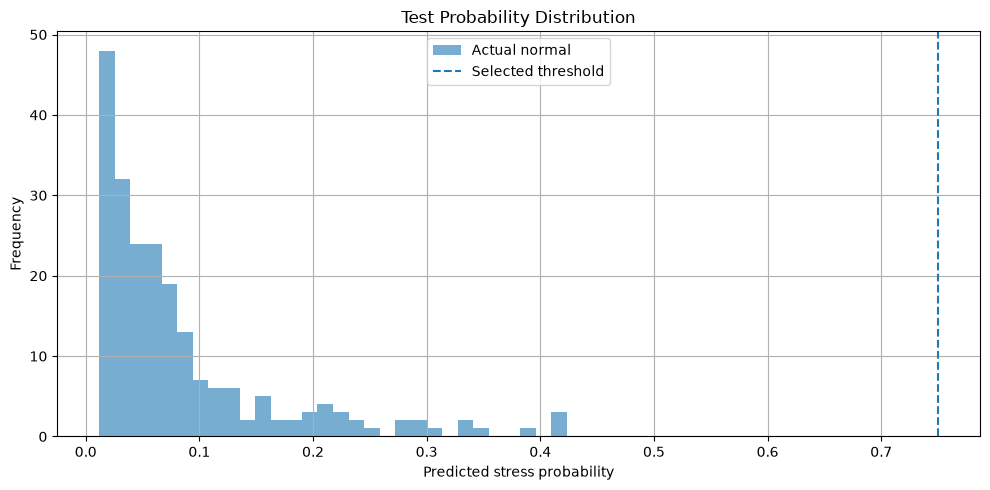

Probability plot saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_test_probability_distribution.png


In [35]:
plt.figure(figsize=(10, 5))

normal_probabilities = test_predictions_df.loc[
    test_predictions_df["actual"] == 0,
    "probability"
]

stress_probabilities = test_predictions_df.loc[
    test_predictions_df["actual"] == 1,
    "probability"
]

if len(normal_probabilities) > 0:
    plt.hist(
        normal_probabilities,
        bins=30,
        alpha=0.6,
        label="Actual normal"
    )

if len(stress_probabilities) > 0:
    plt.hist(
        stress_probabilities,
        bins=30,
        alpha=0.6,
        label="Actual stress"
    )

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label="Selected threshold"
)

plt.xlabel("Predicted stress probability")
plt.ylabel("Frequency")
plt.title("Test Probability Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()

probability_plot_path = (
    OUTPUT_DIR
    / "phase13_gru_test_probability_distribution.png"
)

plt.savefig(
    probability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Probability plot saved to:", probability_plot_path)

In [36]:
checkpoint_path = (
    OUTPUT_DIR
    / "phase13_gru_best_model.pt"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_size": INPUT_SIZE,
    "hidden_size": 32,
    "num_layers": 1,
    "sequence_length": SEQUENCE_LENGTH,
    "feature_columns": feature_columns,
    "positive_class_weight": positive_weight,
    "best_validation_threshold": BEST_THRESHOLD,
    "best_epoch": best_epoch,
    "seed": SEED
}

torch.save(
    checkpoint,
    checkpoint_path
)

print("Model checkpoint saved to:", checkpoint_path)

Model checkpoint saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_best_model.pt


In [37]:
metadata = {
    "project": "FinGraph-Sentinel",
    "phase": 13,
    "model": "Temporal GRU baseline",
    "input_dataset": str(INPUT_PATH),
    "sequence_length": SEQUENCE_LENGTH,
    "feature_columns": feature_columns,
    "feature_count": len(feature_columns),
    "train_rows": len(train_df),
    "validation_rows": len(validation_df),
    "test_rows": len(test_df),
    "train_sequences": len(X_train),
    "validation_sequences": len(X_validation),
    "test_sequences": len(X_test),
    "positive_class_weight": positive_weight,
    "best_epoch": best_epoch,
    "best_validation_threshold": BEST_THRESHOLD,
    "device": str(DEVICE),
    "seed": SEED
}

metadata_path = (
    OUTPUT_DIR
    / "phase13_gru_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
        default=str
    )

print("Metadata saved to:", metadata_path)

Metadata saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_metadata.json


In [38]:
print("=" * 70)
print("PHASE 13 COMPLETION SUMMARY")
print("=" * 70)

print("Input dataset:")
print(INPUT_PATH)

print("\nModel:")
print("Temporal GRU baseline")

print("\nSequence length:")
print(SEQUENCE_LENGTH)

print("\nFeature count:")
print(INPUT_SIZE)

print("\nBest epoch:")
print(best_epoch)

print("\nBest validation threshold:")
print(BEST_THRESHOLD)

print("\nFinal test metrics:")
display(test_metrics_df)

print("\nOutput files:")
for file_path in sorted(OUTPUT_DIR.iterdir()):
    print("-", file_path.name)

print("\nPhase 13 temporal baseline completed.")

PHASE 13 COMPLETION SUMMARY
Input dataset:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_expanded_temporal_dataset.csv

Model:
Temporal GRU baseline

Sequence length:
20

Feature count:
19

Best epoch:
9

Best validation threshold:
0.7500000000000002

Final test metrics:


,threshold,accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc,best_validation_threshold,best_epoch,sequence_length,input_feature_count,positive_class_weight
0,0.75,1.0,0.0,0.0,0.0,0.013981,NaN,NaN,0.75,9,20,19,4.956522



Output files:
- phase13_gru_best_model.pt
- phase13_gru_confusion_matrix.csv
- phase13_gru_metadata.json
- phase13_gru_test_metrics.csv
- phase13_gru_test_predictions.csv
- phase13_gru_test_probability_distribution.png
- phase13_gru_threshold_analysis.png
- phase13_gru_training_history.csv
- phase13_gru_training_history.png
- phase13_gru_validation_metrics.csv
- phase13_gru_validation_predictions.csv
- phase13_gru_validation_thresholds.csv

Phase 13 temporal baseline completed.


In [39]:
# Cell 31: Verify Phase 13 outputs

print("=" * 60)
print("PHASE 13 OUTPUT VERIFICATION")
print("=" * 60)

required_output_files = [
    "phase13_gru_training_history.csv",
    "phase13_gru_validation_predictions.csv",
    "phase13_gru_validation_metrics.csv",
    "phase13_gru_validation_thresholds.csv",
    "phase13_gru_test_predictions.csv",
    "phase13_gru_test_metrics.csv",
    "phase13_gru_confusion_matrix.csv",
    "phase13_gru_best_model.pt",
    "phase13_gru_metadata.json"
]

missing_files = []

for filename in required_output_files:
    file_path = OUTPUT_DIR / filename

    if file_path.exists():
        print("[OK]", filename)
    else:
        print("[MISSING]", filename)
        missing_files.append(filename)

if missing_files:
    raise FileNotFoundError(
        f"\nMissing output files: {missing_files}"
    )

print("\nAll required Phase 13 files are available.")

PHASE 13 OUTPUT VERIFICATION
[OK] phase13_gru_training_history.csv
[OK] phase13_gru_validation_predictions.csv
[OK] phase13_gru_validation_metrics.csv
[OK] phase13_gru_validation_thresholds.csv
[OK] phase13_gru_test_predictions.csv
[OK] phase13_gru_test_metrics.csv
[OK] phase13_gru_confusion_matrix.csv
[OK] phase13_gru_best_model.pt
[OK] phase13_gru_metadata.json

All required Phase 13 files are available.


In [40]:
# Cell 32: Inspect final test metrics

saved_test_metrics = pd.read_csv(
    OUTPUT_DIR / "phase13_gru_test_metrics.csv"
)

print("Final test metrics:")
display(saved_test_metrics.T)

Final test metrics:


,0
threshold,0.750000
accuracy,1.000000
precision,0.000000
recall,0.000000
f1,0.000000
brier_score,0.013981
roc_auc,NaN
pr_auc,NaN
best_validation_threshold,0.750000
best_epoch,9.000000


In [41]:
# Cell 33: Majority-class baseline

majority_class = int(
    pd.Series(y_train.astype(int)).mode()[0]
)

baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class,
    dtype=int
)

baseline_probability = np.full(
    shape=len(y_test),
    fill_value=float(majority_class),
    dtype=float
)

majority_baseline_metrics = calculate_metrics(
    test_actuals,
    baseline_probability,
    threshold=0.5
)

majority_baseline_metrics["model"] = (
    "Majority-class baseline"
)

gru_test_metrics = calculate_metrics(
    test_actuals,
    test_probabilities,
    threshold=BEST_THRESHOLD
)

gru_test_metrics["model"] = (
    "Temporal GRU"
)

baseline_comparison_df = pd.DataFrame(
    [
        majority_baseline_metrics,
        gru_test_metrics
    ]
)

column_order = [
    "model",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "brier_score"
]

baseline_comparison_df = baseline_comparison_df[
    [
        column
        for column in column_order
        if column in baseline_comparison_df.columns
    ]
]

display(baseline_comparison_df)

baseline_comparison_df.to_csv(
    OUTPUT_DIR / "phase13_baseline_comparison.csv",
    index=False
)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Majority-class baseline,0.50,1.0,0.0,0.0,0.0,NaN,NaN,0.000000
1,Temporal GRU,0.75,1.0,0.0,0.0,0.0,NaN,NaN,0.013981


In [42]:
# Cell 34: Compare with previously saved Phase 13 models

comparison_candidates = [
    PROJECT_ROOT
    / "data"
    / "results"
    / "phase13"
    / "phase13_gnn_model_comparison.csv",

    PROJECT_ROOT
    / "data"
    / "results"
    / "phase13"
    / "phase13_temporal_gnn_validation_metrics.csv"
]

available_comparison_files = [
    path
    for path in comparison_candidates
    if path.exists()
]

if not available_comparison_files:
    print(
        "No earlier comparison file was found. "
        "Skipping historical model comparison."
    )
else:
    for comparison_file in available_comparison_files:
        print("\nFile:", comparison_file)
        historical_comparison = pd.read_csv(
            comparison_file
        )
        display(historical_comparison)


File: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_gnn_model_comparison.csv


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score
0,GCN + GRU,0.857143,0.0,0.0,0.0,0.382155,0.111280,0.142536
1,GCN + Temporal Attention,0.857143,0.0,0.0,0.0,0.282216,0.099508,0.143882



File: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_temporal_gnn_validation_metrics.csv


,model,split,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score
0,FinGraph Temporal GNN,validation,0.857143,0.0,0.0,0.0,0.282216,0.099508,0.143882


In [43]:
# Cell 35: Test threshold comparison

reporting_thresholds = [
    0.5,
    BEST_THRESHOLD
]

test_threshold_results = []

for threshold in reporting_thresholds:
    metrics = calculate_metrics(
        test_actuals,
        test_probabilities,
        threshold=threshold
    )

    metrics["threshold_source"] = (
        "default_0.5"
        if threshold == 0.5
        else "selected_on_validation"
    )

    test_threshold_results.append(metrics)

test_threshold_results_df = pd.DataFrame(
    test_threshold_results
)

display(test_threshold_results_df)

test_threshold_results_df.to_csv(
    OUTPUT_DIR / "phase13_test_threshold_reporting.csv",
    index=False
)

,threshold,accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc,threshold_source
0,0.50,1.0,0.0,0.0,0.0,0.013981,NaN,NaN,default_0.5
1,0.75,1.0,0.0,0.0,0.0,0.013981,NaN,NaN,selected_on_validation


In [44]:
# Cell 36: Probability ranking diagnostics

ranking_summary = {
    "normal_count": int((test_actuals == 0).sum()),
    "stress_count": int((test_actuals == 1).sum()),
    "normal_mean_probability": np.nan,
    "stress_mean_probability": np.nan,
    "normal_median_probability": np.nan,
    "stress_median_probability": np.nan
}

normal_mask = test_actuals == 0
stress_mask = test_actuals == 1

if normal_mask.sum() > 0:
    ranking_summary[
        "normal_mean_probability"
    ] = float(
        test_probabilities[normal_mask].mean()
    )

    ranking_summary[
        "normal_median_probability"
    ] = float(
        np.median(test_probabilities[normal_mask])
    )

if stress_mask.sum() > 0:
    ranking_summary[
        "stress_mean_probability"
    ] = float(
        test_probabilities[stress_mask].mean()
    )

    ranking_summary[
        "stress_median_probability"
    ] = float(
        np.median(test_probabilities[stress_mask])
    )

ranking_summary_df = pd.DataFrame(
    [ranking_summary]
)

display(ranking_summary_df)

ranking_summary_df.to_csv(
    OUTPUT_DIR / "phase13_probability_ranking_summary.csv",
    index=False
)

,normal_count,stress_count,normal_mean_probability,stress_mean_probability,normal_median_probability,stress_median_probability
0,215,0,0.083053,NaN,0.05639,NaN


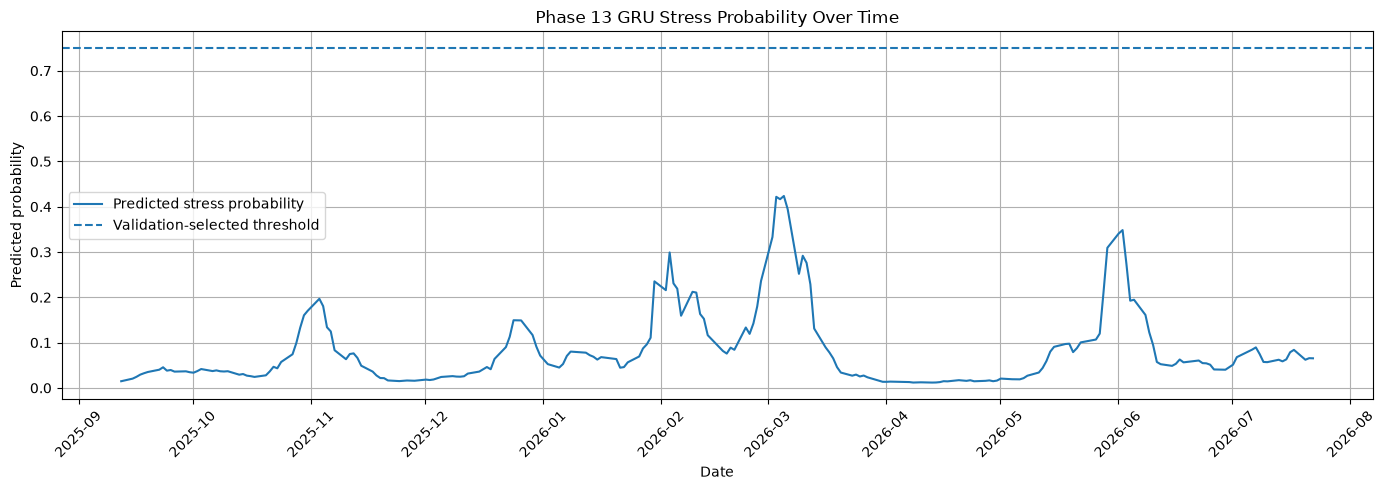

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_gru_temporal_probability_plot.png


In [45]:
# Cell 37: Temporal probability plot

plot_df = test_predictions_df.copy()

plot_df["date"] = pd.to_datetime(
    plot_df["date"]
)

plot_df = plot_df.sort_values(
    "date"
)

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["date"],
    plot_df["probability"],
    label="Predicted stress probability"
)

plt.axhline(
    BEST_THRESHOLD,
    linestyle="--",
    label="Validation-selected threshold"
)

stress_dates = plot_df.loc[
    plot_df["actual"] == 1,
    "date"
]

for stress_date in stress_dates:
    plt.axvline(
        stress_date,
        alpha=0.15
    )

plt.xlabel("Date")
plt.ylabel("Predicted probability")
plt.title("Phase 13 GRU Stress Probability Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

temporal_probability_plot_path = (
    OUTPUT_DIR
    / "phase13_gru_temporal_probability_plot.png"
)

plt.savefig(
    temporal_probability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    temporal_probability_plot_path
)

In [46]:
# Cell 38: Save experiment summary

experiment_summary = {
    "project": "FinGraph-Sentinel",
    "phase": 13,
    "model": "Temporal GRU baseline",
    "sequence_length": int(SEQUENCE_LENGTH),
    "feature_count": int(INPUT_SIZE),
    "training_sequences": int(len(X_train)),
    "validation_sequences": int(len(X_validation)),
    "test_sequences": int(len(X_test)),
    "best_epoch": int(best_epoch),
    "best_validation_loss": float(best_validation_loss),
    "positive_class_weight": float(positive_weight),
    "validation_selected_threshold": float(BEST_THRESHOLD),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
    "test_f1": float(test_metrics["f1"]),
    "test_roc_auc": float(test_metrics["roc_auc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),
    "test_brier_score": float(test_metrics["brier_score"])
}

experiment_summary_df = pd.DataFrame(
    [experiment_summary]
)

display(experiment_summary_df.T)

experiment_summary_df.to_csv(
    OUTPUT_DIR / "phase13_complete_experiment_summary.csv",
    index=False
)

print(
    "Experiment summary saved successfully."
)

,0
project,FinGraph-Sentinel
phase,13
model,Temporal GRU baseline
sequence_length,20
feature_count,19
training_sequences,685
validation_sequences,215
test_sequences,215
best_epoch,9
best_validation_loss,0.247466


Experiment summary saved successfully.


In [47]:
# Cell 39: Final validation checklist

checks = {
    "Input dataset exists": INPUT_PATH.exists(),
    "Output directory exists": OUTPUT_DIR.exists(),
    "No missing feature values": (
        not np.isnan(X_train).any()
        and not np.isnan(X_validation).any()
        and not np.isnan(X_test).any()
    ),
    "Training contains both classes": (
        len(np.unique(y_train)) == 2
    ),
    "Validation contains both classes": (
        len(np.unique(y_validation)) == 2
    ),
    "Chronological split": (
        train_df[DATE_COLUMN].max()
        < validation_df[DATE_COLUMN].min()
        and validation_df[DATE_COLUMN].max()
        < test_df[DATE_COLUMN].min()
    ),
    "Model checkpoint exists": (
        OUTPUT_DIR / "phase13_gru_best_model.pt"
    ).exists()
}

for check_name, result in checks.items():
    print(
        "[PASS]" if result else "[FAIL]",
        check_name
    )

if not all(checks.values()):
    print(
        "\nSome checks failed. "
        "Review them before using the results in your paper."
    )
else:
    print(
        "\nAll Phase 13 validation checks passed."
    )

[PASS] Input dataset exists
[PASS] Output directory exists
[PASS] No missing feature values
[PASS] Training contains both classes
[PASS] Validation contains both classes
[PASS] Chronological split
[PASS] Model checkpoint exists

All Phase 13 validation checks passed.


In [48]:
print("Selected feature columns:")
print(f"Total features: {len(feature_columns)}\n")

for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {feature}")

Selected feature columns:
Total features: 19

01. nodes
02. edges
03. density
04. average_degree
05. average_strength
06. average_clustering
07. connected_components
08. degree_concentration
09. market_return
10. market_volatility
11. return_dispersion
12. negative_fraction
13. market_index
14. running_peak
15. drawdown
16. future_return_20d
17. future_max_drawdown_20d
18. future_volatility_20d
19. future_negative_fraction_20d


In [49]:
leakage_keywords = [
    "future",
    "target",
    "next",
    "forward",
    "lead",
    "label",
    "event",
    "outcome",
    "horizon",
    "t+"
]

potential_leakage = []

for feature in feature_columns:
    feature_lower = feature.lower()

    if any(keyword in feature_lower for keyword in leakage_keywords):
        potential_leakage.append(feature)

print("Potentially leakage-prone features:\n")

if potential_leakage:
    for feature in potential_leakage:
        print(f"- {feature}")
else:
    print("No potentially leakage-prone features detected by name.")

Potentially leakage-prone features:

- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d


In [50]:
feature_audit = []

for feature in feature_columns:
    feature_lower = feature.lower()

    matched_keywords = [
        keyword
        for keyword in leakage_keywords
        if keyword in feature_lower
    ]

    feature_audit.append({
        "feature": feature,
        "potential_leakage": len(matched_keywords) > 0,
        "matched_keywords": ", ".join(matched_keywords)
    })

feature_audit_df = pd.DataFrame(feature_audit)

display(feature_audit_df)

feature_audit_path = OUTPUT_DIR / "feature_leakage_audit.csv"
feature_audit_df.to_csv(feature_audit_path, index=False)

print(f"Saved feature audit to: {feature_audit_path}")

,feature,potential_leakage,matched_keywords
0,nodes,False,
1,edges,False,
2,density,False,
3,average_degree,False,
4,average_strength,False,
5,average_clustering,False,
6,connected_components,False,
7,degree_concentration,False,
8,market_return,False,
9,market_volatility,False,


Saved feature audit to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\feature_leakage_audit.csv


In [51]:
audit_df = df[feature_columns + [TARGET_COLUMN]].copy()

missing_report = audit_df.isna().sum()
infinite_report = np.isinf(
    audit_df.select_dtypes(include=[np.number])
).sum()

data_quality_report = pd.DataFrame({
    "missing_values": missing_report,
    "infinite_values": infinite_report.reindex(
        missing_report.index,
        fill_value=0
    )
})

display(data_quality_report)

print("Total missing values:", data_quality_report["missing_values"].sum())
print("Total infinite values:", data_quality_report["infinite_values"].sum())

,missing_values,infinite_values
nodes,0,0
edges,0,0
density,0,0
average_degree,0,0
average_strength,0,0
average_clustering,0,0
connected_components,0,0
degree_concentration,0,0
market_return,0,0
market_volatility,0,0


Total missing values: 0
Total infinite values: 0


In [52]:
duplicate_dates = df[df[DATE_COLUMN].duplicated(keep=False)]

print("Total rows:", len(df))
print("Unique dates:", df[DATE_COLUMN].nunique())
print("Duplicate date rows:", len(duplicate_dates))

if len(duplicate_dates) > 0:
    display(duplicate_dates[[DATE_COLUMN, TARGET_COLUMN]].head(20))
else:
    print("No duplicate dates found.")

Total rows: 1175
Unique dates: 1175
Duplicate date rows: 0
No duplicate dates found.


In [53]:
split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "start_date": [
        train_df[DATE_COLUMN].min(),
        validation_df[DATE_COLUMN].min(),
        test_df[DATE_COLUMN].min()
    ],
    "end_date": [
        train_df[DATE_COLUMN].max(),
        validation_df[DATE_COLUMN].max(),
        test_df[DATE_COLUMN].max()
    ]
})

display(split_summary)

,split,rows,start_date,end_date
0,Train,705,2021-11-12 05:00:00,2024-09-04 04:00:00
1,Validation,235,2024-09-05 04:00:00,2025-08-13 04:00:00
2,Test,235,2025-08-14 04:00:00,2026-07-22 04:00:00


In [54]:
train_end = train_df[DATE_COLUMN].max()
validation_start = validation_df[DATE_COLUMN].min()
validation_end = validation_df[DATE_COLUMN].max()
test_start = test_df[DATE_COLUMN].min()

print("Chronological split validation:\n")

print("Train ends before validation starts:",
      train_end < validation_start)

print("Validation ends before test starts:",
      validation_end < test_start)

if train_end < validation_start and validation_end < test_start:
    print("\nPASS: Splits are chronologically ordered.")
else:
    print("\nWARNING: Check chronological split boundaries.")

Chronological split validation:

Train ends before validation starts: True
Validation ends before test starts: True

PASS: Splits are chronologically ordered.


In [57]:
# Cell 47 — Check Target Distribution

target_distribution = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts(),
    "Validation": pd.Series(y_validation).value_counts(),
    "Test": pd.Series(y_test).value_counts()
}).fillna(0).astype(int)

display(target_distribution)

print("\nTarget proportions:")

for split_name, target_values in [
    ("Train", y_train),
    ("Validation", y_validation),
    ("Test", y_test)
]:
    proportions = (
        pd.Series(target_values)
        .value_counts(normalize=True)
        .sort_index()
    )

    print(f"\n{split_name}:")
    print(proportions)

,Train,Validation,Test
0.0,570,182,215
1.0,115,33,0



Target proportions:

Train:
0.0    0.832117
1.0    0.167883
Name: proportion, dtype: float64

Validation:
0.0    0.846512
1.0    0.153488
Name: proportion, dtype: float64

Test:
0.0    1.0
Name: proportion, dtype: float64


In [58]:
train_correlation_df = train_df[feature_columns + [TARGET_COLUMN]].copy()

train_correlations = (
    train_correlation_df
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .abs()
    .sort_values(ascending=False)
)

display(
    train_correlations.to_frame(
        name="absolute_correlation_with_target"
    )
)

,absolute_correlation_with_target
future_volatility_20d,0.645445
future_max_drawdown_20d,0.619610
future_return_20d,0.489636
edges,0.421629
average_degree,0.421629
density,0.421629
average_strength,0.417459
future_negative_fraction_20d,0.343483
average_clustering,0.339627
connected_components,0.324435


In [59]:
dataset_audit = {
    "total_rows": len(df),
    "total_features": len(feature_columns),
    "unique_dates": int(df[DATE_COLUMN].nunique()),
    "duplicate_date_rows": int(len(duplicate_dates)),
    "missing_values": int(df.isna().sum().sum()),
    "infinite_values": int(
        np.isinf(
            df.select_dtypes(include=[np.number])
        ).sum().sum()
    ),
    "train_rows": len(train_df),
    "validation_rows": len(validation_df),
    "test_rows": len(test_df),
    "train_start": str(train_df[DATE_COLUMN].min()),
    "train_end": str(train_df[DATE_COLUMN].max()),
    "validation_start": str(validation_df[DATE_COLUMN].min()),
    "validation_end": str(validation_df[DATE_COLUMN].max()),
    "test_start": str(test_df[DATE_COLUMN].min()),
    "test_end": str(test_df[DATE_COLUMN].max()),
    "potential_leakage_features": potential_leakage
}

dataset_audit_path = OUTPUT_DIR / "dataset_audit_report.json"

with open(dataset_audit_path, "w", encoding="utf-8") as file:
    json.dump(dataset_audit, file, indent=4, default=str)

print(f"Dataset audit saved to:\n{dataset_audit_path}")

Dataset audit saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\dataset_audit_report.json


In [60]:
print("=" * 70)
print("PHASE 13 DATASET AUDIT SUMMARY")
print("=" * 70)

print(f"Total rows: {len(df)}")
print(f"Total selected features: {len(feature_columns)}")
print(f"Unique dates: {df[DATE_COLUMN].nunique()}")
print(f"Duplicate date rows: {len(duplicate_dates)}")
print(f"Missing values: {df.isna().sum().sum()}")

print("\nPotential leakage-prone features:")
if potential_leakage:
    for feature in potential_leakage:
        print(f"- {feature}")
else:
    print("None detected by keyword screening.")

print("\nChronological split:")
print(f"Train:      {train_df[DATE_COLUMN].min()} → {train_df[DATE_COLUMN].max()}")
print(f"Validation: {validation_df[DATE_COLUMN].min()} → {validation_df[DATE_COLUMN].max()}")
print(f"Test:       {test_df[DATE_COLUMN].min()} → {test_df[DATE_COLUMN].max()}")

print("\nAudit files saved:")
print(f"- {feature_audit_path}")
print(f"- {dataset_audit_path}")

print("\nNext step:")
print("Review potential leakage features before final research evaluation.")

PHASE 13 DATASET AUDIT SUMMARY
Total rows: 1175
Total selected features: 19
Unique dates: 1175
Duplicate date rows: 0
Missing values: 0

Potential leakage-prone features:
- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d

Chronological split:
Train:      2021-11-12 05:00:00 → 2024-09-04 04:00:00
Validation: 2024-09-05 04:00:00 → 2025-08-13 04:00:00
Test:       2025-08-14 04:00:00 → 2026-07-22 04:00:00

Audit files saved:
- C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\feature_leakage_audit.csv
- C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\dataset_audit_report.json

Next step:
Review potential leakage features before final research evaluation.


In [61]:
# Cell 51 — Review Potential Leakage Features

print("Potential leakage-prone features:")

if potential_leakage:
    for i, feature in enumerate(potential_leakage, start=1):
        print(f"{i}. {feature}")
else:
    print("No potential leakage features detected.")

Potential leakage-prone features:
1. future_return_20d
2. future_max_drawdown_20d
3. future_volatility_20d
4. future_negative_fraction_20d


In [62]:
# Cell 52 — Define Confirmed Leakage Features

# Add only features that are confirmed to contain future information.
CONFIRMED_LEAKAGE_FEATURES = [
    # Example:
    # "future_max_stress"
]

invalid_exclusions = [
    feature
    for feature in CONFIRMED_LEAKAGE_FEATURES
    if feature not in feature_columns
]

if invalid_exclusions:
    raise ValueError(
        f"These exclusion features do not exist: {invalid_exclusions}"
    )

verified_feature_columns = [
    feature
    for feature in feature_columns
    if feature not in CONFIRMED_LEAKAGE_FEATURES
]

print("Original feature count:", len(feature_columns))
print("Removed feature count:", len(CONFIRMED_LEAKAGE_FEATURES))
print("Verified feature count:", len(verified_feature_columns))

print("\nVerified features:")
for feature in verified_feature_columns:
    print("-", feature)

Original feature count: 19
Removed feature count: 0
Verified feature count: 19

Verified features:
- nodes
- edges
- density
- average_degree
- average_strength
- average_clustering
- connected_components
- degree_concentration
- market_return
- market_volatility
- return_dispersion
- negative_fraction
- market_index
- running_peak
- drawdown
- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d


In [63]:
# Cell 53 — Compare Feature Sets

removed_features = [
    feature
    for feature in feature_columns
    if feature not in verified_feature_columns
]

print("Removed features:")
if removed_features:
    for feature in removed_features:
        print("-", feature)
else:
    print("No features removed.")

print("\nVerified feature count:", len(verified_feature_columns))

Removed features:
No features removed.

Verified feature count: 19


In [64]:
# Cell 54 — Verify Feature Data Types

non_numeric_features = [
    feature
    for feature in verified_feature_columns
    if not pd.api.types.is_numeric_dtype(df[feature])
]

if non_numeric_features:
    print("Non-numeric features found:")
    for feature in non_numeric_features:
        print("-", feature)

    raise TypeError(
        "All model features must be numeric. Review the listed columns."
    )

print("PASS: All verified features are numeric.")

PASS: All verified features are numeric.


In [65]:
# Cell 55 — Check Zero-Variance Features

feature_variances = df[verified_feature_columns].var()

zero_variance_features = feature_variances[
    feature_variances == 0
].index.tolist()

print("Zero-variance features:")

if zero_variance_features:
    for feature in zero_variance_features:
        print("-", feature)
else:
    print("None found.")

Zero-variance features:
- nodes


In [66]:
# Cell 56 — Create Final Verified Feature List

final_feature_columns = [
    feature
    for feature in verified_feature_columns
    if feature not in zero_variance_features
]

print("Final feature count:", len(final_feature_columns))

print("\nFinal features:")
for feature in final_feature_columns:
    print("-", feature)

Final feature count: 18

Final features:
- edges
- density
- average_degree
- average_strength
- average_clustering
- connected_components
- degree_concentration
- market_return
- market_volatility
- return_dispersion
- negative_fraction
- market_index
- running_peak
- drawdown
- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d


In [67]:
# Cell 57 — Save Final Feature List

final_feature_report = pd.DataFrame({
    "feature": final_feature_columns
})

final_feature_path = OUTPUT_DIR / "final_verified_feature_list.csv"

final_feature_report.to_csv(
    final_feature_path,
    index=False
)

print(f"Final feature list saved to:\n{final_feature_path}")

Final feature list saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\final_verified_feature_list.csv


In [68]:
# Cell 58 — Create Final Dataset Snapshot

final_dataset = df[
    [DATE_COLUMN] + final_feature_columns + [TARGET_COLUMN]
].copy()

print("Final dataset shape:", final_dataset.shape)

display(final_dataset.head())

Final dataset shape: (1175, 20)


,date,edges,density,average_degree,average_strength,average_clustering,connected_components,degree_concentration,market_return,market_volatility,return_dispersion,negative_fraction,market_index,running_peak,drawdown,future_return_20d,future_max_drawdown_20d,future_volatility_20d,future_negative_fraction_20d,future_stress_event
0,2021-11-12 05:00:00,8,0.177778,1.6,1.004483,0.134435,5,1.280625,0.010352,0.017581,0.017581,0.2,1.010352,1.010352,0.000000,-0.012822,-0.038069,0.015409,0.50,0
1,2021-11-15 05:00:00,7,0.155556,1.4,0.903223,0.180070,5,1.200000,-0.001608,0.009776,0.009776,0.6,1.008727,1.010352,-0.001608,-0.018331,-0.036519,0.015477,0.50,0
2,2021-11-16 05:00:00,6,0.133333,1.2,0.797787,0.221044,6,1.166190,0.007416,0.014972,0.014972,0.4,1.016208,1.016208,0.000000,-0.003358,-0.043612,0.016229,0.50,0
3,2021-11-17 05:00:00,6,0.133333,1.2,0.795784,0.220136,6,1.166190,-0.006493,0.022268,0.022268,0.5,1.009609,1.016208,-0.006493,-0.017053,-0.037361,0.016764,0.50,0
4,2021-11-18 05:00:00,7,0.155556,1.4,0.911687,0.182034,5,1.200000,0.012402,0.030239,0.030239,0.4,1.022131,1.022131,0.000000,-0.037287,-0.049154,0.016563,0.55,0


In [69]:
# Cell 59 — Final Dataset Quality Check

numeric_data = final_dataset[
    final_feature_columns
].select_dtypes(include=[np.number])

missing_values = final_dataset.isna().sum().sum()
infinite_values = np.isinf(numeric_data.to_numpy()).sum()

print("Missing values:", missing_values)
print("Infinite values:", infinite_values)
print("Rows:", len(final_dataset))
print("Features:", len(final_feature_columns))

if missing_values > 0:
    raise ValueError("Missing values detected in the final dataset.")

if infinite_values > 0:
    raise ValueError("Infinite values detected in the final dataset.")

print("\nPASS: Final dataset contains no missing or infinite values.")

Missing values: 0
Infinite values: 0
Rows: 1175
Features: 18

PASS: Final dataset contains no missing or infinite values.


In [70]:
# Cell 60 — Save Final Dataset

final_dataset_path = OUTPUT_DIR / "phase13_final_verified_dataset.csv"

final_dataset.to_csv(
    final_dataset_path,
    index=False
)

print(f"Final verified dataset saved to:\n{final_dataset_path}")

Final verified dataset saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\phase13_final_verified_dataset.csv


In [71]:
# Cell 61 — Final Audit Decision

audit_passed = (
    len(final_feature_columns) > 0
    and missing_values == 0
    and infinite_values == 0
    and len(duplicate_dates) == 0
)

print("=" * 70)
print("FINAL DATASET AUDIT DECISION")
print("=" * 70)

print("Features available:", len(final_feature_columns))
print("Missing values:", missing_values)
print("Infinite values:", infinite_values)
print("Duplicate date rows:", len(duplicate_dates))

if audit_passed:
    print("\nPASS: Dataset is ready for the next controlled experiment.")
else:
    print("\nWARNING: Dataset requires further review.")

FINAL DATASET AUDIT DECISION
Features available: 18
Missing values: 0
Infinite values: 0
Duplicate date rows: 0

PASS: Dataset is ready for the next controlled experiment.


In [72]:
# Cell 62 — Define Graph and Results Directories

GRAPH_DIRECTORIES = [
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "data" / "results"
]

for directory in GRAPH_DIRECTORIES:
    print(f"\nDirectory: {directory}")
    print("Exists:", directory.exists())


Directory: C:\Users\ADMIN\FinGraph-Sentinel\data\processed
Exists: True

Directory: C:\Users\ADMIN\FinGraph-Sentinel\data\results
Exists: True


In [73]:
# Cell 63 — Find Graph-Related Files

graph_keywords = [
    "graph",
    "network",
    "edge",
    "node",
    "snapshot",
    "community",
    "shock",
    "contagion"
]

graph_files = []

for directory in GRAPH_DIRECTORIES:
    if directory.exists():
        for file_path in directory.rglob("*"):
            if file_path.is_file():
                file_name = file_path.name.lower()

                if any(keyword in file_name for keyword in graph_keywords):
                    graph_files.append(file_path)

graph_files = sorted(set(graph_files))

print(f"Graph-related files found: {len(graph_files)}\n")

for file_path in graph_files:
    print(file_path)

Graph-related files found: 6

C:\Users\ADMIN\FinGraph-Sentinel\data\processed\community_analysis.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\processed\financial_graph.gml
C:\Users\ADMIN\FinGraph-Sentinel\data\processed\graph_metrics.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\dynamic_shock_propagation.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\network_evolution.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\node_network_evolution.csv


In [74]:
# Cell 64 — Display Graph File Metadata

graph_file_metadata = []

for file_path in graph_files:
    graph_file_metadata.append({
        "file_name": file_path.name,
        "extension": file_path.suffix,
        "size_kb": round(file_path.stat().st_size / 1024, 2),
        "path": str(file_path)
    })

graph_file_metadata_df = pd.DataFrame(graph_file_metadata)

display(graph_file_metadata_df)

,file_name,extension,size_kb,path
0,community_analysis.csv,.csv,0.21,C:\Users\ADMIN\FinGraph-Sentinel\data\processe...
1,financial_graph.gml,.gml,0.62,C:\Users\ADMIN\FinGraph-Sentinel\data\processe...
2,graph_metrics.csv,.csv,1.24,C:\Users\ADMIN\FinGraph-Sentinel\data\processe...
3,dynamic_shock_propagation.csv,.csv,4.90,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
4,network_evolution.csv,.csv,12.19,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
5,node_network_evolution.csv,.csv,90.24,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...


In [75]:
# Cell 65 — Inspect CSV Graph Files

csv_graph_files = [
    file_path
    for file_path in graph_files
    if file_path.suffix.lower() == ".csv"
]

for file_path in csv_graph_files:
    print("\n" + "=" * 80)
    print("FILE:", file_path)
    print("=" * 80)

    try:
        temp_df = pd.read_csv(file_path)

        print("Shape:", temp_df.shape)
        print("Columns:")
        print(list(temp_df.columns))

        display(temp_df.head(3))

    except Exception as error:
        print("Could not read file:", error)


FILE: C:\Users\ADMIN\FinGraph-Sentinel\data\processed\community_analysis.csv
Shape: (7, 3)
Columns:
['Community', 'Average_Volatility', 'Company_Count']


,Community,Average_Volatility,Company_Count
0,0,0.020296,3
1,1,0.014775,2
2,2,0.017664,1



FILE: C:\Users\ADMIN\FinGraph-Sentinel\data\processed\graph_metrics.csv
Shape: (10, 9)
Columns:
['Ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score']


,Ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score
0,NVDA,0,0.000000,0.000000,0.0,0.026087,10.113162,0.032695,2.030459
1,GOOGL,1,0.620722,0.111111,0.0,0.134895,1.571132,0.020229,0.388028
2,JPM,0,0.000000,0.000000,0.0,0.026087,1.624696,0.015383,0.332765



FILE: C:\Users\ADMIN\FinGraph-Sentinel\data\results\dynamic_shock_propagation.csv
Shape: (120, 4)
Columns:
['date', 'shocked_company', 'total_impact', 'affected_companies']


,date,shocked_company,total_impact,affected_companies
0,2021-11-12 05:00:00,AAPL,0.371987,4
1,2021-11-29 05:00:00,AAPL,0.379675,4
2,2021-12-13 05:00:00,AAPL,0.316338,3



FILE: C:\Users\ADMIN\FinGraph-Sentinel\data\results\network_evolution.csv
Shape: (120, 10)
Columns:
['nodes', 'edges', 'density', 'average_degree', 'average_clustering', 'connected_components', 'date', 'edge_change', 'density_change', 'clustering_change']


,nodes,edges,density,average_degree,average_clustering,connected_components,date,edge_change,density_change,clustering_change
0,10,8,0.177778,1.6,0.200000,5,2021-11-12 05:00:00,NaN,NaN,NaN
1,10,9,0.200000,1.8,0.433333,5,2021-11-29 05:00:00,0.125,0.125,1.166667
2,10,9,0.200000,1.8,0.433333,5,2021-12-13 05:00:00,0.000,0.000,0.000000



FILE: C:\Users\ADMIN\FinGraph-Sentinel\data\results\node_network_evolution.csv
Shape: (600, 12)
Columns:
['date', 'ticker', 'degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change']


,date,ticker,degree,strength,betweenness,closeness,eigenvector,degree_change,strength_change,betweenness_change,closeness_change,eigenvector_change
0,2021-11-12 05:00:00,AAPL,3,1.719874,0.0,0.829037,0.479096,NaN,NaN,NaN,NaN,NaN
1,2021-12-13 05:00:00,AAPL,2,1.163385,0.0,0.819259,0.286102,-1.0,-0.556490,0.0,-0.009777,-0.192994
2,2022-01-11 05:00:00,AAPL,3,1.723417,0.0,0.949838,0.400180,1.0,0.560033,0.0,0.130578,0.114078


In [76]:
# Cell 66 — Inspect GML Files Safely

gml_files = [
    file_path
    for file_path in graph_files
    if file_path.suffix.lower() == ".gml"
]

if gml_files:
    print("GML files found:\n")

    for file_path in gml_files:
        print("-", file_path)
        print("Size:", round(file_path.stat().st_size / 1024, 2), "KB")

    print(
        "\nWARNING: Do not load these GML files until their format "
        "has been verified."
    )
else:
    print("No GML files found.")

GML files found:

- C:\Users\ADMIN\FinGraph-Sentinel\data\processed\financial_graph.gml
Size: 0.62 KB



In [77]:
# Cell 67 — Search for Temporal Result Files

temporal_keywords = [
    "temporal",
    "dynamic",
    "evolution",
    "shock",
    "systemic",
    "ews"
]

temporal_files = []

results_directory = PROJECT_ROOT / "data" / "results"

if results_directory.exists():
    for file_path in results_directory.rglob("*"):
        if file_path.is_file():
            file_name = file_path.name.lower()

            if any(keyword in file_name for keyword in temporal_keywords):
                temporal_files.append(file_path)

temporal_files = sorted(set(temporal_files))

print(f"Temporal files found: {len(temporal_files)}\n")

for file_path in temporal_files:
    print(file_path)

Temporal files found: 13

C:\Users\ADMIN\FinGraph-Sentinel\data\results\dynamic_shock_propagation.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\dynamic_systemic_risk.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\network_evolution.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\node_network_evolution.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_expanded_temporal_dataset.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_temporal_gnn_test_predictions.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_temporal_gnn_validation_metrics.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\phase13_temporal_gnn_validation_predictions.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\temporal_gnn_test_predictions.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\temporal_gnn_train_predictions.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13\temporal_gnn_training_history.csv
C:\Users\ADMIN\FinGraph-Sentinel

In [78]:
# Cell 68 — Create Graph Data Inventory

graph_inventory = []

for file_path in graph_files + temporal_files:
    if not file_path.exists():
        continue

    graph_inventory.append({
        "file_name": file_path.name,
        "file_type": file_path.suffix.lower(),
        "file_size_kb": round(file_path.stat().st_size / 1024, 2),
        "absolute_path": str(file_path)
    })

graph_inventory_df = (
    pd.DataFrame(graph_inventory)
    .drop_duplicates()
    .sort_values("file_name")
    .reset_index(drop=True)
)

display(graph_inventory_df)

inventory_path = OUTPUT_DIR / "graph_data_inventory.csv"

graph_inventory_df.to_csv(
    inventory_path,
    index=False
)

print(f"Inventory saved to:\n{inventory_path}")

,file_name,file_type,file_size_kb,absolute_path
0,community_analysis.csv,.csv,0.21,C:\Users\ADMIN\FinGraph-Sentinel\data\processe...
1,dynamic_shock_propagation.csv,.csv,4.90,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
2,dynamic_systemic_risk.csv,.csv,101.47,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
3,financial_graph.gml,.gml,0.62,C:\Users\ADMIN\FinGraph-Sentinel\data\processe...
4,graph_metrics.csv,.csv,1.24,C:\Users\ADMIN\FinGraph-Sentinel\data\processe...
5,network_evolution.csv,.csv,12.19,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
6,node_network_evolution.csv,.csv,90.24,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
7,phase13_expanded_temporal_dataset.csv,.csv,350.79,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
8,phase13_gru_temporal_probability_plot.png,.png,236.40,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
9,phase13_temporal_gnn_test_predictions.csv,.csv,10.82,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...


Inventory saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\graph_data_inventory.csv


In [79]:
# Cell 69 — Graph Reconstruction Diagnostic

print("=" * 80)
print("GRAPH RECONSTRUCTION DIAGNOSTIC")
print("=" * 80)

print("Total graph-related files:", len(graph_files))
print("Total temporal files:", len(temporal_files))
print("CSV graph files:", len(csv_graph_files))
print("GML files:", len(gml_files))

print("\nCurrent status:")
print("- Temporal GRU baseline: completed")
print("- Dataset audit: completed")
print("- Graph file inventory: completed")
print("- Genuine temporal GNN: not started")

print(
    "\nNext requirement: identify the exact node-feature and edge-index "
    "structure used in Phases 8–12."
)

GRAPH RECONSTRUCTION DIAGNOSTIC
Total graph-related files: 6
Total temporal files: 13
CSV graph files: 5
GML files: 1

Current status:
- Temporal GRU baseline: completed
- Dataset audit: completed
- Graph file inventory: completed
- Genuine temporal GNN: not started

Next requirement: identify the exact node-feature and edge-index structure used in Phases 8–12.


In [80]:
import pandas as pd
from pathlib import Path

NODE_EVOLUTION_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "node_network_evolution.csv"
)

NETWORK_EVOLUTION_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "network_evolution.csv"
)

SHOCK_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "dynamic_shock_propagation.csv"
)

node_evolution = pd.read_csv(NODE_EVOLUTION_PATH)
network_evolution = pd.read_csv(NETWORK_EVOLUTION_PATH)
shock_propagation = pd.read_csv(SHOCK_PATH)

print("Node evolution shape:", node_evolution.shape)
print("Network evolution shape:", network_evolution.shape)
print("Shock propagation shape:", shock_propagation.shape)

Node evolution shape: (600, 12)
Network evolution shape: (120, 10)
Shock propagation shape: (120, 4)


In [81]:
print("NODE EVOLUTION COLUMNS")
print(node_evolution.columns.tolist())

print("\nNODE EVOLUTION DATA TYPES")
print(node_evolution.dtypes)

print("\nUNIQUE TICKERS")
print(node_evolution["ticker"].unique())

print("\nUNIQUE DATE COUNT")
print(node_evolution["date"].nunique())

print("\nROWS PER DATE")
print(node_evolution.groupby("date").size().value_counts().sort_index())

print("\nMISSING VALUES")
print(node_evolution.isna().sum())

print("\nFIRST 10 ROWS")
display(node_evolution.head(10))

NODE EVOLUTION COLUMNS
['date', 'ticker', 'degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change']

NODE EVOLUTION DATA TYPES
date                      str
ticker                    str
degree                  int64
strength              float64
betweenness           float64
closeness             float64
eigenvector           float64
degree_change         float64
strength_change       float64
betweenness_change    float64
closeness_change      float64
eigenvector_change    float64
dtype: object

UNIQUE TICKERS
<StringArray>
['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']
Length: 10, dtype: str

UNIQUE DATE COUNT
60

ROWS PER DATE
10    60
Name: count, dtype: int64

MISSING VALUES
date                   0
ticker                 0
degree                 0
strength               0
betweenness            0
closeness              0
eigenvector            0


,date,ticker,degree,strength,betweenness,closeness,eigenvector,degree_change,strength_change,betweenness_change,closeness_change,eigenvector_change
0,2021-11-12 05:00:00,AAPL,3,1.719874,0.000000,0.829037,0.479096,NaN,NaN,NaN,NaN,NaN
1,2021-12-13 05:00:00,AAPL,2,1.163385,0.000000,0.819259,0.286102,-1.0,-0.556490,0.000000,-0.009777,-0.192994
2,2022-01-11 05:00:00,AAPL,3,1.723417,0.000000,0.949838,0.400180,1.0,0.560033,0.000000,0.130578,0.114078
3,2022-02-09 05:00:00,AAPL,4,2.560198,0.000000,1.449449,0.413622,1.0,0.836780,0.000000,0.499611,0.013442
4,2022-03-10 05:00:00,AAPL,6,4.301159,0.055556,2.437032,0.383564,2.0,1.740961,0.055556,0.987583,-0.030058
5,2022-04-07 04:00:00,AAPL,9,6.061263,0.277778,3.062540,0.393159,3.0,1.760104,0.222222,0.625508,0.009595
6,2022-05-06 04:00:00,AAPL,9,6.785231,0.027778,4.063629,0.358851,0.0,0.723968,-0.250000,1.001089,-0.034309
7,2022-06-06 04:00:00,AAPL,9,6.785605,0.027778,4.064316,0.347299,0.0,0.000375,0.000000,0.000688,-0.011551
8,2022-07-06 04:00:00,AAPL,9,7.030472,0.027778,4.569622,0.347968,0.0,0.244866,0.000000,0.505306,0.000669
9,2022-08-03 04:00:00,AAPL,9,6.863191,0.000000,4.211888,0.337025,0.0,-0.167281,-0.027778,-0.357735,-0.010943


In [82]:
date_company_counts = (
    node_evolution
    .groupby("date")["ticker"]
    .nunique()
    .reset_index(name="company_count")
)

print(date_company_counts["company_count"].value_counts())

incomplete_dates = date_company_counts[
    date_company_counts["company_count"] != 10
]

print("Incomplete dates:", len(incomplete_dates))

if len(incomplete_dates) > 0:
    display(incomplete_dates.head(20))
else:
    print("Every date contains all 10 companies.")

company_count
10    60
Name: count, dtype: int64
Incomplete dates: 0
Every date contains all 10 companies.


In [83]:
print("NETWORK EVOLUTION COLUMNS")
print(network_evolution.columns.tolist())

print("\nNETWORK EVOLUTION DATA TYPES")
print(network_evolution.dtypes)

print("\nNETWORK EVOLUTION MISSING VALUES")
print(network_evolution.isna().sum())

print("\nNETWORK EVOLUTION SUMMARY")
display(network_evolution.describe(include="all"))

print("\nFIRST 10 ROWS")
display(network_evolution.head(10))

NETWORK EVOLUTION COLUMNS
['nodes', 'edges', 'density', 'average_degree', 'average_clustering', 'connected_components', 'date', 'edge_change', 'density_change', 'clustering_change']

NETWORK EVOLUTION DATA TYPES
nodes                     int64
edges                     int64
density                 float64
average_degree          float64
average_clustering      float64
connected_components      int64
date                        str
edge_change             float64
density_change          float64
clustering_change       float64
dtype: object

NETWORK EVOLUTION MISSING VALUES
nodes                    0
edges                    0
density                  0
average_degree           0
average_clustering       0
connected_components     0
date                     0
edge_change              1
density_change           1
clustering_change       19
dtype: int64

NETWORK EVOLUTION SUMMARY


,nodes,edges,density,average_degree,average_clustering,connected_components,date,edge_change,density_change,clustering_change
count,120.0,120.000000,120.000000,120.000000,120.000000,120.000000,120,119.000000,119.000000,101.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,120,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-12 05:00:00,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
mean,10.0,16.300000,0.362222,3.260000,0.469530,3.750000,NaN,0.041946,0.041946,inf
std,0.0,14.112156,0.313603,2.822431,0.332091,2.348788,NaN,0.329396,0.329396,NaN
min,10.0,1.000000,0.022222,0.200000,0.000000,1.000000,NaN,-0.780488,-0.780488,-1.000000
25%,10.0,6.000000,0.133333,1.200000,0.233333,1.000000,NaN,-0.117647,-0.117647,-0.100000
50%,10.0,10.000000,0.222222,2.000000,0.450000,3.500000,NaN,0.000000,0.000000,0.000000
75%,10.0,25.000000,0.555556,5.000000,0.769365,5.000000,NaN,0.163333,0.163333,0.110945



FIRST 10 ROWS


,nodes,edges,density,average_degree,average_clustering,connected_components,date,edge_change,density_change,clustering_change
0,10,8,0.177778,1.6,0.200000,5,2021-11-12 05:00:00,NaN,NaN,NaN
1,10,9,0.200000,1.8,0.433333,5,2021-11-29 05:00:00,0.125000,0.125000,1.166667
2,10,9,0.200000,1.8,0.433333,5,2021-12-13 05:00:00,0.000000,0.000000,0.000000
3,10,9,0.200000,1.8,0.333333,5,2021-12-28 05:00:00,0.000000,0.000000,-0.230769
4,10,9,0.200000,1.8,0.333333,5,2022-01-11 05:00:00,0.000000,0.000000,0.000000
5,10,15,0.333333,3.0,0.500000,3,2022-01-26 05:00:00,0.666667,0.666667,0.500000
6,10,15,0.333333,3.0,0.450000,2,2022-02-09 05:00:00,0.000000,0.000000,-0.100000
7,10,23,0.511111,4.6,0.727619,2,2022-02-24 05:00:00,0.533333,0.533333,0.616931
8,10,25,0.555556,5.0,0.772857,2,2022-03-10 05:00:00,0.086957,0.086957,0.062173
9,10,29,0.644444,5.8,0.793333,2,2022-03-24 04:00:00,0.160000,0.160000,0.026494


In [84]:
print("SHOCK PROPAGATION COLUMNS")
print(shock_propagation.columns.tolist())

print("\nSHOCK PROPAGATION DATA TYPES")
print(shock_propagation.dtypes)

print("\nSHOCK PROPAGATION MISSING VALUES")
print(shock_propagation.isna().sum())

print("\nSHOCKED COMPANIES")
print(shock_propagation["shocked_company"].value_counts())

print("\nFIRST 10 ROWS")
display(shock_propagation.head(10))

SHOCK PROPAGATION COLUMNS
['date', 'shocked_company', 'total_impact', 'affected_companies']

SHOCK PROPAGATION DATA TYPES
date                      str
shocked_company           str
total_impact          float64
affected_companies      int64
dtype: object

SHOCK PROPAGATION MISSING VALUES
date                  0
shocked_company       0
total_impact          0
affected_companies    0
dtype: int64

SHOCKED COMPANIES
shocked_company
AAPL    120
Name: count, dtype: int64

FIRST 10 ROWS


,date,shocked_company,total_impact,affected_companies
0,2021-11-12 05:00:00,AAPL,0.371987,4
1,2021-11-29 05:00:00,AAPL,0.379675,4
2,2021-12-13 05:00:00,AAPL,0.316338,3
3,2021-12-28 05:00:00,AAPL,0.368796,4
4,2022-01-11 05:00:00,AAPL,0.372342,4
5,2022-01-26 05:00:00,AAPL,0.507009,6
6,2022-02-09 05:00:00,AAPL,0.456020,5
7,2022-02-24 05:00:00,AAPL,0.639477,8
8,2022-03-10 05:00:00,AAPL,0.630116,7
9,2022-03-24 04:00:00,AAPL,0.743092,9


In [85]:
all_csv_files = list(
    (PROJECT_ROOT / "data").rglob("*.csv")
)

edge_related_files = []

edge_keywords = [
    "edge",
    "adjacency",
    "connection",
    "correlation",
    "network"
]

for file_path in all_csv_files:
    file_name = file_path.name.lower()

    if any(keyword in file_name for keyword in edge_keywords):
        edge_related_files.append(file_path)

print("Potential edge-related CSV files:")

for file_path in edge_related_files:
    print(file_path)

Potential edge-related CSV files:
C:\Users\ADMIN\FinGraph-Sentinel\data\processed\correlation_matrix.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\network_evolution.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\node_network_evolution.csv


In [86]:
all_files = list(
    (PROJECT_ROOT / "data").rglob("*")
)

possible_edge_snapshots = []

for file_path in all_files:
    if not file_path.is_file():
        continue

    file_name = file_path.name.lower()

    edge_terms = [
        "edge",
        "adjacency",
        "snapshot",
        "correlation"
    ]

    if any(term in file_name for term in edge_terms):
        possible_edge_snapshots.append(file_path)

print("Potential edge or snapshot files:")

for file_path in possible_edge_snapshots:
    print(file_path)

Potential edge or snapshot files:
C:\Users\ADMIN\FinGraph-Sentinel\data\processed\correlation_matrix.csv


In [88]:
CORRELATION_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "correlation_matrix.csv"
)

correlation_matrix = pd.read_csv(
    CORRELATION_PATH,
    index_col=0
)

print("Shape:", correlation_matrix.shape)
print("Index:", correlation_matrix.index.tolist())
print("Columns:", correlation_matrix.columns.tolist())

display(correlation_matrix)

Shape: (10, 10)
Index: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']
Columns: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']


,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
ticker,,,,,,,,,,
AAPL,1.000000,0.493822,0.517332,0.359589,0.483266,0.446402,0.531562,0.477481,0.467205,0.465803
AMZN,0.493822,1.000000,0.620722,0.351348,0.419459,0.587168,0.610041,0.529928,0.441086,0.381786
GOOGL,0.517332,0.620722,1.000000,0.317552,0.372011,0.533398,0.547861,0.500806,0.416744,0.346192
JPM,0.359589,0.351348,0.317552,1.000000,0.477558,0.297858,0.296517,0.327722,0.319858,0.477821
MA,0.483266,0.419459,0.372011,0.477558,1.000000,0.394143,0.455410,0.351428,0.283375,0.881086
META,0.446402,0.587168,0.533398,0.297858,0.394143,1.000000,0.510159,0.484114,0.350974,0.346475
MSFT,0.531562,0.610041,0.547861,0.296517,0.455410,0.510159,1.000000,0.565413,0.384953,0.402555
NVDA,0.477481,0.529928,0.500806,0.327722,0.351428,0.484114,0.565413,1.000000,0.463387,0.322008
TSLA,0.467205,0.441086,0.416744,0.319858,0.283375,0.350974,0.384953,0.463387,1.000000,0.293520


In [89]:
RETURNS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "returns.csv"
)

returns = pd.read_csv(RETURNS_PATH)

print("Shape:", returns.shape)
print("Columns:", returns.columns.tolist())
print("Data types:")
print(returns.dtypes)

display(returns.head())
display(returns.tail())

Shape: (1254, 11)
Columns: ['date', 'AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']
Data types:
date         str
AAPL     float64
AMZN     float64
GOOGL    float64
JPM      float64
MA       float64
META     float64
MSFT     float64
NVDA     float64
TSLA     float64
V        float64
dtype: object


,date,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
0,2021-08-20 04:00:00,0.010156,0.003827,0.012894,0.002852,-0.006493,0.011968,0.025576,0.051419,0.010082,-0.000907
1,2021-08-23 04:00:00,0.010257,0.020600,0.019006,0.012797,0.016958,0.011075,0.000952,0.054862,0.038280,0.012016
2,2021-08-24 04:00:00,-0.000601,0.012220,0.008712,0.006190,0.002133,0.005945,-0.006663,-0.007514,0.003101,0.000427
3,2021-08-25 04:00:00,-0.008421,-0.001997,0.005787,0.020613,-0.007407,0.007879,-0.002016,0.019272,0.003825,-0.007044
4,2021-08-26 04:00:00,-0.005528,0.005098,-0.004494,0.005158,-0.017377,-0.010885,-0.009669,-0.006528,-0.014117,-0.008900


,date,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
1249,2026-08-13 04:00:00,0.009959,-0.008044,0.008209,-0.005668,0.013060,0.027848,0.009037,0.005400,0.038014,0.016777
1250,2026-08-14 04:00:00,0.002195,-0.009354,-0.001328,-0.000744,0.003968,-0.008605,-0.002979,-0.000621,0.006795,-0.003557
1251,2026-08-17 04:00:00,-0.001111,-0.005102,-0.005493,-0.005181,-0.012349,-0.035399,-0.030379,-0.000666,-0.008677,-0.014582
1252,2026-08-18 04:00:00,0.014529,-0.007118,0.000581,0.006344,0.021431,-0.044466,0.002665,-0.023421,-0.007162,0.015076
1253,2026-08-19 04:00:00,0.019659,0.019927,0.004605,-0.016325,0.003395,0.014200,0.010153,-0.002184,0.030872,0.013507


In [90]:
expected_tickers = sorted([
    "AAPL", "AMZN", "GOOGL", "JPM", "MA",
    "META", "MSFT", "NVDA", "TSLA", "V"
])

matrix_tickers = sorted(
    [str(column) for column in correlation_matrix.columns]
)

print("Expected tickers:", expected_tickers)
print("Matrix tickers:", matrix_tickers)

print(
    "Ticker sets match:",
    expected_tickers == matrix_tickers
)

Expected tickers: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']
Matrix tickers: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']
Ticker sets match: True


In [91]:
import numpy as np

corr_values = correlation_matrix.astype(float)

threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    edge_count = 0

    for i in range(len(corr_values.columns)):
        for j in range(i + 1, len(corr_values.columns)):
            correlation = abs(
                corr_values.iloc[i, j]
            )

            if correlation >= threshold:
                edge_count += 1

    threshold_results.append({
        "threshold": threshold,
        "undirected_edges": edge_count
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,undirected_edges
0,0.3,41
1,0.4,27
2,0.5,12
3,0.6,3
4,0.7,1
5,0.8,1
6,0.9,0


In [92]:
network_evolution["date"] = pd.to_datetime(
    network_evolution["date"],
    errors="coerce"
)

print("Observed edge count distribution:")
display(
    network_evolution["edges"]
    .value_counts()
    .sort_index()
)

print("\nObserved edge count summary:")
display(
    network_evolution["edges"].describe()
)

Observed edge count distribution:


edges
1      1
2     10
3      8
4      2
5      6
6      9
7      4
8      6
9     13
10     3
11     4
12     4
14     2
15     7
16     1
17     3
18     2
19     1
20     1
23     2
25     2
26     1
29     1
31     1
32     2
33     2
35     2
36     2
40     1
41     3
42     3
43     4
44     1
45     6
Name: count, dtype: int64


Observed edge count summary:


count    120.000000
mean      16.300000
std       14.112156
min        1.000000
25%        6.000000
50%       10.000000
75%       25.000000
max       45.000000
Name: edges, dtype: float64

In [93]:
import pandas as pd
import numpy as np

returns = pd.read_csv(RETURNS_PATH)

returns["date"] = pd.to_datetime(
    returns["date"],
    errors="coerce"
)

returns = (
    returns
    .dropna(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

tickers = [
    "AAPL", "AMZN", "GOOGL", "JPM", "MA",
    "META", "MSFT", "NVDA", "TSLA", "V"
]

returns = returns[["date"] + tickers].copy()

print("Returns shape:", returns.shape)
print("Date range:", returns["date"].min(), "to", returns["date"].max())
print("Missing values:", returns[tickers].isna().sum().sum())

display(returns.head())

Returns shape: (1254, 11)
Date range: 2021-08-20 04:00:00 to 2026-08-19 04:00:00
Missing values: 0


,date,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
0,2021-08-20 04:00:00,0.010156,0.003827,0.012894,0.002852,-0.006493,0.011968,0.025576,0.051419,0.010082,-0.000907
1,2021-08-23 04:00:00,0.010257,0.020600,0.019006,0.012797,0.016958,0.011075,0.000952,0.054862,0.038280,0.012016
2,2021-08-24 04:00:00,-0.000601,0.012220,0.008712,0.006190,0.002133,0.005945,-0.006663,-0.007514,0.003101,0.000427
3,2021-08-25 04:00:00,-0.008421,-0.001997,0.005787,0.020613,-0.007407,0.007879,-0.002016,0.019272,0.003825,-0.007044
4,2021-08-26 04:00:00,-0.005528,0.005098,-0.004494,0.005158,-0.017377,-0.010885,-0.009669,-0.006528,-0.014117,-0.008900


In [94]:
def build_correlation_edges(
    window_returns,
    threshold=0.5
):
    """
    Build undirected edges using absolute Pearson correlation.

    An edge is created when:
        abs(correlation) >= threshold

    Returns:
        list of dictionaries containing source, target, weight
    """

    correlation = window_returns.corr()

    edges = []

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):

            source = tickers[i]
            target = tickers[j]

            value = correlation.loc[source, target]

            if pd.isna(value):
                continue

            if abs(value) >= threshold:
                edges.append({
                    "source": source,
                    "target": target,
                    "weight": float(value)
                })

    return edges

In [95]:
TEST_WINDOW = 60
TEST_THRESHOLD = 0.5

test_returns = returns[tickers].iloc[:TEST_WINDOW]

test_edges = build_correlation_edges(
    test_returns,
    threshold=TEST_THRESHOLD
)

print("Window size:", TEST_WINDOW)
print("Threshold:", TEST_THRESHOLD)
print("Reconstructed edges:", len(test_edges))

display(pd.DataFrame(test_edges))

Window size: 60
Threshold: 0.5
Reconstructed edges: 8


,source,target,weight
0,AAPL,AMZN,0.632925
1,AAPL,GOOGL,0.538511
2,AAPL,MSFT,0.548438
3,AMZN,GOOGL,0.581516
4,AMZN,NVDA,0.502811
5,GOOGL,MSFT,0.819789
6,MA,V,0.897322
7,MSFT,NVDA,0.501101


In [96]:
node_evolution["date"] = pd.to_datetime(
    node_evolution["date"],
    errors="coerce"
)

node_dates = sorted(
    node_evolution["date"].dropna().unique()
)

print("Node evolution dates:", len(node_dates))
print("First date:", node_dates[0])
print("Last date:", node_dates[-1])

Node evolution dates: 60
First date: 2021-11-12 05:00:00
Last date: 2026-07-30 04:00:00


In [97]:
WINDOW_SIZE = 60
CORRELATION_THRESHOLD = 0.5

reconstructed_graphs = []

for current_date in node_dates:

    historical_returns = returns[
        returns["date"] <= current_date
    ].tail(WINDOW_SIZE)

    if len(historical_returns) < WINDOW_SIZE:
        continue

    edges = build_correlation_edges(
        historical_returns[tickers],
        threshold=CORRELATION_THRESHOLD
    )

    reconstructed_graphs.append({
        "date": current_date,
        "nodes": len(tickers),
        "edges": len(edges),
        "threshold": CORRELATION_THRESHOLD,
        "window_size": WINDOW_SIZE
    })

reconstructed_graphs_df = pd.DataFrame(
    reconstructed_graphs
)

print(
    "Reconstructed graph snapshots:",
    len(reconstructed_graphs_df)
)

display(reconstructed_graphs_df.head())

Reconstructed graph snapshots: 60


,date,nodes,edges,threshold,window_size
0,2021-11-12 05:00:00,10,8,0.5,60
1,2021-12-13 05:00:00,10,9,0.5,60
2,2022-01-11 05:00:00,10,9,0.5,60
3,2022-02-09 05:00:00,10,15,0.5,60
4,2022-03-10 05:00:00,10,25,0.5,60


In [98]:
recorded_network = network_evolution.copy()

recorded_network["date"] = pd.to_datetime(
    recorded_network["date"],
    errors="coerce"
)

comparison = reconstructed_graphs_df.merge(
    recorded_network[["date", "edges"]],
    on="date",
    how="inner",
    suffixes=("_reconstructed", "_recorded")
)

comparison["absolute_difference"] = (
    comparison["edges_reconstructed"]
    - comparison["edges_recorded"]
).abs()

comparison["signed_difference"] = (
    comparison["edges_reconstructed"]
    - comparison["edges_recorded"]
)

print("Matched dates:", len(comparison))

display(comparison.head(20))

print("\nMean absolute edge-count difference:")
print(comparison["absolute_difference"].mean())

print("\nExact edge-count matches:")
print(
    (
        comparison["absolute_difference"] == 0
    ).sum()
)

Matched dates: 60


,date,nodes,edges_reconstructed,threshold,window_size,edges_recorded,absolute_difference,signed_difference
0,2021-11-12 05:00:00,10,8,0.5,60,8,0,0
1,2021-12-13 05:00:00,10,9,0.5,60,9,0,0
2,2022-01-11 05:00:00,10,9,0.5,60,9,0,0
3,2022-02-09 05:00:00,10,15,0.5,60,15,0,0
4,2022-03-10 05:00:00,10,25,0.5,60,25,0,0
5,2022-04-07 04:00:00,10,31,0.5,60,31,0,0
6,2022-05-06 04:00:00,10,41,0.5,60,41,0,0
7,2022-06-06 04:00:00,10,44,0.5,60,44,0,0
8,2022-07-06 04:00:00,10,43,0.5,60,43,0,0
9,2022-08-03 04:00:00,10,45,0.5,60,45,0,0



Mean absolute edge-count difference:
0.0

Exact edge-count matches:
60


In [99]:
experiment_results = []

window_sizes = [20, 30, 60, 90]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for window_size in window_sizes:

    for threshold in thresholds:

        reconstructed = []

        for current_date in node_dates:

            historical_returns = returns[
                returns["date"] <= current_date
            ].tail(window_size)

            if len(historical_returns) < window_size:
                continue

            edges = build_correlation_edges(
                historical_returns[tickers],
                threshold=threshold
            )

            reconstructed.append({
                "date": current_date,
                "edges_reconstructed": len(edges)
            })

        reconstructed_df = pd.DataFrame(reconstructed)

        if reconstructed_df.empty:
            continue

        comparison_temp = reconstructed_df.merge(
            recorded_network[["date", "edges"]],
            on="date",
            how="inner"
        )

        if comparison_temp.empty:
            continue

        comparison_temp["absolute_difference"] = (
            comparison_temp["edges_reconstructed"]
            - comparison_temp["edges"]
        ).abs()

        experiment_results.append({
            "window_size": window_size,
            "threshold": threshold,
            "matched_dates": len(comparison_temp),
            "mean_absolute_difference": (
                comparison_temp["absolute_difference"].mean()
            ),
            "exact_matches": (
                comparison_temp["absolute_difference"] == 0
            ).sum()
        })

experiment_results_df = pd.DataFrame(
    experiment_results
).sort_values(
    "mean_absolute_difference"
)

display(experiment_results_df)

,window_size,threshold,matched_dates,mean_absolute_difference,exact_matches
12,60,0.5,60,0.000000,60
17,90,0.5,58,3.603448,9
7,30,0.5,60,5.066667,4
13,60,0.6,60,5.583333,5
8,30,0.6,60,5.700000,8
11,60,0.4,60,5.916667,3
16,90,0.4,58,6.224138,4
3,20,0.6,60,6.733333,3
2,20,0.5,60,7.233333,4
18,90,0.6,58,7.396552,1


In [100]:
RECONSTRUCTION_OUTPUT = (
    OUTPUT_DIR
    / "temporal_graph_reconstruction_experiments.csv"
)

experiment_results_df.to_csv(
    RECONSTRUCTION_OUTPUT,
    index=False
)

print(
    "Saved:",
    RECONSTRUCTION_OUTPUT
)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_graph_reconstruction_experiments.csv


In [101]:
from pathlib import Path
import pandas as pd
import numpy as np

GRAPH_OUTPUT_DIR = (
    OUTPUT_DIR / "reconstructed_temporal_graphs"
)

GRAPH_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

WINDOW_SIZE = 60
CORRELATION_THRESHOLD = 0.5

temporal_edges = []
temporal_graph_summary = []

for snapshot_id, current_date in enumerate(node_dates):

    historical_returns = returns[
        returns["date"] <= current_date
    ].tail(WINDOW_SIZE)

    if len(historical_returns) < WINDOW_SIZE:
        continue

    edges = build_correlation_edges(
        historical_returns[tickers],
        threshold=CORRELATION_THRESHOLD
    )

    date_string = pd.Timestamp(current_date).strftime(
        "%Y-%m-%d"
    )

    edge_file = (
        GRAPH_OUTPUT_DIR
        / f"edges_{snapshot_id:03d}_{date_string}.csv"
    )

    edges_df = pd.DataFrame(edges)

    if edges_df.empty:
        edges_df = pd.DataFrame(
            columns=["source", "target", "weight"]
        )

    edges_df.to_csv(
        edge_file,
        index=False
    )

    temporal_graph_summary.append({
        "snapshot_id": snapshot_id,
        "date": current_date,
        "nodes": len(tickers),
        "edges": len(edges_df),
        "window_size": WINDOW_SIZE,
        "correlation_threshold": CORRELATION_THRESHOLD,
        "edge_file": str(edge_file)
    })

    for edge in edges:
        temporal_edges.append({
            "snapshot_id": snapshot_id,
            "date": current_date,
            "source": edge["source"],
            "target": edge["target"],
            "weight": edge["weight"]
        })

temporal_graph_summary_df = pd.DataFrame(
    temporal_graph_summary
)

temporal_edges_df = pd.DataFrame(
    temporal_edges
)

print(
    "Generated snapshots:",
    len(temporal_graph_summary_df)
)

print(
    "Generated edges:",
    len(temporal_edges_df)
)

display(temporal_graph_summary_df.head())
display(temporal_edges_df.head())

Generated snapshots: 60
Generated edges: 979


,snapshot_id,date,nodes,edges,window_size,correlation_threshold,edge_file
0,0,2021-11-12 05:00:00,10,8,60,0.5,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
1,1,2021-12-13 05:00:00,10,9,60,0.5,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
2,2,2022-01-11 05:00:00,10,9,60,0.5,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
3,3,2022-02-09 05:00:00,10,15,60,0.5,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...
4,4,2022-03-10 05:00:00,10,25,60,0.5,C:\Users\ADMIN\FinGraph-Sentinel\data\results\...


,snapshot_id,date,source,target,weight
0,0,2021-11-12 05:00:00,AAPL,AMZN,0.632925
1,0,2021-11-12 05:00:00,AAPL,GOOGL,0.538511
2,0,2021-11-12 05:00:00,AAPL,MSFT,0.548438
3,0,2021-11-12 05:00:00,AMZN,GOOGL,0.581516
4,0,2021-11-12 05:00:00,AMZN,NVDA,0.502811


In [102]:
validation = temporal_graph_summary_df.merge(
    recorded_network[["date", "edges"]],
    on="date",
    how="inner",
    suffixes=("_reconstructed", "_recorded")
)

validation["edge_count_difference"] = (
    validation["edges_reconstructed"]
    - validation["edges_recorded"]
)

print("Matched dates:", len(validation))

print(
    "Maximum absolute difference:",
    validation["edge_count_difference"]
    .abs()
    .max()
)

print(
    "Exact matches:",
    (
        validation["edge_count_difference"] == 0
    ).sum()
)

assert (
    validation["edge_count_difference"]
    .abs()
    .max() == 0
), "Edge-count validation failed."

print("Edge-count validation passed.")

Matched dates: 60
Maximum absolute difference: 0
Exact matches: 60
Edge-count validation passed.


In [103]:
SUMMARY_PATH = (
    GRAPH_OUTPUT_DIR
    / "temporal_graph_summary.csv"
)

EDGES_PATH = (
    GRAPH_OUTPUT_DIR
    / "temporal_edges_all.csv"
)

VALIDATION_PATH = (
    GRAPH_OUTPUT_DIR
    / "edge_count_validation.csv"
)

temporal_graph_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

temporal_edges_df.to_csv(
    EDGES_PATH,
    index=False
)

validation.to_csv(
    VALIDATION_PATH,
    index=False
)

print("Saved files:")
print(SUMMARY_PATH)
print(EDGES_PATH)
print(VALIDATION_PATH)

Saved files:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\reconstructed_temporal_graphs\temporal_graph_summary.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\reconstructed_temporal_graphs\temporal_edges_all.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\reconstructed_temporal_graphs\edge_count_validation.csv


In [104]:
print("Edge weight statistics:")

display(
    temporal_edges_df["weight"].describe()
)

print("\nMinimum edge weight:")
print(temporal_edges_df["weight"].min())

print("\nMaximum edge weight:")
print(temporal_edges_df["weight"].max())

print("\nMissing edge weights:")
print(
    temporal_edges_df["weight"].isna().sum()
)

print("\nSelf-loops:")
print(
    (
        temporal_edges_df["source"]
        == temporal_edges_df["target"]
    ).sum()
)

Edge weight statistics:


count    979.000000
mean       0.663492
std        0.108669
min        0.500031
25%        0.568245
50%        0.650767
75%        0.747127
max        0.959005
Name: weight, dtype: float64


Minimum edge weight:
0.5000312937079515

Maximum edge weight:
0.9590050504275419

Missing edge weights:
0

Self-loops:
0


In [105]:
comparison_plot_df = validation.sort_values("date").copy()

display(
    comparison_plot_df[
        [
            "date",
            "edges_reconstructed",
            "edges_recorded",
            "edge_count_difference"
        ]
    ]
)

,date,edges_reconstructed,edges_recorded,edge_count_difference
0,2021-11-12 05:00:00,8,8,0
1,2021-12-13 05:00:00,9,9,0
2,2022-01-11 05:00:00,9,9,0
3,2022-02-09 05:00:00,15,15,0
4,2022-03-10 05:00:00,25,25,0
5,2022-04-07 04:00:00,31,31,0
6,2022-05-06 04:00:00,41,41,0
7,2022-06-06 04:00:00,44,44,0
8,2022-07-06 04:00:00,43,43,0
9,2022-08-03 04:00:00,45,45,0


In [106]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


In [107]:
node_features_df = node_evolution.copy()

node_features_df["date"] = pd.to_datetime(
    node_features_df["date"],
    errors="coerce"
)

node_features_df["date"] = (
    node_features_df["date"].dt.normalize()
)

node_features_df = node_features_df.sort_values(
    ["date", "ticker"]
).reset_index(drop=True)

print("Shape:", node_features_df.shape)
print("Unique dates:", node_features_df["date"].nunique())
print("Unique tickers:", node_features_df["ticker"].nunique())

display(node_features_df.head())

Shape: (600, 12)
Unique dates: 60
Unique tickers: 10


,date,ticker,degree,strength,betweenness,closeness,eigenvector,degree_change,strength_change,betweenness_change,closeness_change,eigenvector_change
0,2021-11-12,AAPL,3,1.719874,0.000000,0.829037,4.790957e-01,NaN,NaN,NaN,NaN,NaN
1,2021-11-12,AMZN,3,1.717252,0.027778,0.944901,4.333795e-01,NaN,NaN,NaN,NaN,NaN
2,2021-11-12,GOOGL,3,1.939815,0.027778,1.022125,5.272720e-01,NaN,NaN,NaN,NaN,NaN
3,2021-11-12,JPM,0,0.000000,0.000000,0.000000,4.298179e-14,NaN,NaN,NaN,NaN,NaN
4,2021-11-12,MA,1,0.897322,0.000000,1.082135,9.495506e-06,NaN,NaN,NaN,NaN,NaN


In [108]:
NODE_EXCLUDE_COLUMNS = [
    "date",
    "ticker"
]

node_feature_columns = [
    column
    for column in node_features_df.columns
    if column not in NODE_EXCLUDE_COLUMNS
]

print("Selected node features:")
print(node_feature_columns)

node_features_df[node_feature_columns] = (
    node_features_df[node_feature_columns]
    .apply(pd.to_numeric, errors="coerce")
)

node_features_df[node_feature_columns] = (
    node_features_df[node_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

print("\nMissing values:")
print(
    node_features_df[node_feature_columns]
    .isna()
    .sum()
)

Selected node features:
['degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change']

Missing values:
degree                0
strength              0
betweenness           0
closeness             0
eigenvector           0
degree_change         0
strength_change       0
betweenness_change    0
closeness_change      0
eigenvector_change    0
dtype: int64


In [109]:
NODE_ORDER = sorted(tickers)

available_tickers = sorted(
    node_features_df["ticker"].unique()
)

assert available_tickers == NODE_ORDER, (
    f"Ticker mismatch.\n"
    f"Expected: {NODE_ORDER}\n"
    f"Found: {available_tickers}"
)

date_counts = (
    node_features_df
    .groupby("date")["ticker"]
    .nunique()
)

assert (date_counts == len(NODE_ORDER)).all(), (
    "Some dates do not contain all 10 companies."
)

print("Node order verified.")
print("Every date contains all 10 companies.")

Node order verified.
Every date contains all 10 companies.


In [110]:
graph_dates = sorted(
    node_features_df["date"].unique()
)

X_graphs = []

for current_date in graph_dates:

    date_data = (
        node_features_df[
            node_features_df["date"] == current_date
        ]
        .set_index("ticker")
        .reindex(NODE_ORDER)
    )

    feature_matrix = date_data[
        node_feature_columns
    ].to_numpy(dtype=np.float32)

    assert feature_matrix.shape == (
        len(NODE_ORDER),
        len(node_feature_columns)
    )

    X_graphs.append(feature_matrix)

X_graphs = np.stack(X_graphs)

print("Graph feature tensor shape:")
print(X_graphs.shape)

print(
    "Expected format:",
    "(number_of_dates, number_of_nodes, number_of_features)"
)

Graph feature tensor shape:
(60, 10, 10)
Expected format: (number_of_dates, number_of_nodes, number_of_features)


In [111]:
num_graph_dates = len(graph_dates)

train_end = int(num_graph_dates * 0.60)
val_end = int(num_graph_dates * 0.80)

feature_scaler = StandardScaler()

train_features_2d = X_graphs[
    :train_end
].reshape(-1, X_graphs.shape[-1])

feature_scaler.fit(train_features_2d)

X_graphs_scaled = feature_scaler.transform(
    X_graphs.reshape(-1, X_graphs.shape[-1])
).reshape(X_graphs.shape)

print("Scaled tensor shape:", X_graphs_scaled.shape)
print("Training graph dates:", train_end)
print("Validation graph dates:", val_end - train_end)
print("Test graph dates:", num_graph_dates - val_end)

Scaled tensor shape: (60, 10, 10)
Training graph dates: 36
Validation graph dates: 12
Test graph dates: 12


In [112]:
edge_files = sorted(
    GRAPH_OUTPUT_DIR.glob("edges_*.csv")
)

assert len(edge_files) == len(graph_dates), (
    f"Edge files: {len(edge_files)}, "
    f"Graph dates: {len(graph_dates)}"
)

edge_indices = []
edge_weights = []

ticker_to_index = {
    ticker: index
    for index, ticker in enumerate(NODE_ORDER)
}

for edge_file in edge_files:

    edges_df = pd.read_csv(edge_file)

    current_edges = []
    current_weights = []

    for _, edge in edges_df.iterrows():

        source = edge["source"]
        target = edge["target"]
        weight = float(edge["weight"])

        source_index = ticker_to_index[source]
        target_index = ticker_to_index[target]

        # Add both directions for an undirected graph
        current_edges.append(
            [source_index, target_index]
        )

        current_edges.append(
            [target_index, source_index]
        )

        current_weights.append(abs(weight))
        current_weights.append(abs(weight))

    if len(current_edges) == 0:
        current_edges = [
            [i, i]
            for i in range(len(NODE_ORDER))
        ]

        current_weights = [
            1.0
            for _ in range(len(NODE_ORDER))
        ]

    edge_index = torch.tensor(
        current_edges,
        dtype=torch.long
    ).t().contiguous()

    edge_weight = torch.tensor(
        current_weights,
        dtype=torch.float32
    )

    edge_indices.append(edge_index)
    edge_weights.append(edge_weight)

print("Number of edge snapshots:", len(edge_indices))
print("First edge index shape:", edge_indices[0].shape)
print("First edge weight shape:", edge_weights[0].shape)

Number of edge snapshots: 60
First edge index shape: torch.Size([2, 16])
First edge weight shape: torch.Size([16])


In [113]:
for index, edge_index in enumerate(edge_indices):

    assert edge_index.shape[0] == 2

    assert edge_index.min() >= 0
    assert edge_index.max() < len(NODE_ORDER)

    assert edge_weights[index].shape[0] == (
        edge_index.shape[1]
    )

print("All edge indices are valid.")
print("All edge weights are aligned.")

All edge indices are valid.
All edge weights are aligned.


In [114]:
target_df = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "results"
    / "phase13"
    / "phase13_expanded_temporal_dataset.csv"
)

target_df["date"] = pd.to_datetime(
    target_df["date"],
    errors="coerce"
)

target_df["date"] = (
    target_df["date"].dt.normalize()
)

target_df = (
    target_df[
        ["date", "future_stress_event"]
    ]
    .drop_duplicates("date")
    .sort_values("date")
)

target_df["future_stress_event"] = (
    pd.to_numeric(
        target_df["future_stress_event"],
        errors="coerce"
    )
)

target_df = target_df.dropna(
    subset=["future_stress_event"]
)

target_df["future_stress_event"] = (
    target_df["future_stress_event"]
    .astype(int)
)

display(target_df.head())
print("Target distribution:")
print(
    target_df["future_stress_event"].value_counts()
)

,date,future_stress_event
0,2021-11-12,0
1,2021-11-15,0
2,2021-11-16,0
3,2021-11-17,0
4,2021-11-18,0


Target distribution:
future_stress_event
0    1027
1     148
Name: count, dtype: int64


In [115]:
graph_date_df = pd.DataFrame({
    "date": pd.to_datetime(graph_dates)
})

aligned_data = graph_date_df.merge(
    target_df,
    on="date",
    how="inner"
)

print("Graph dates:", len(graph_date_df))
print("Target dates:", len(target_df))
print("Aligned dates:", len(aligned_data))

display(aligned_data.head())

Graph dates: 60
Target dates: 1175
Aligned dates: 59


,date,future_stress_event
0,2021-11-12,0
1,2021-12-13,0
2,2022-01-11,0
3,2022-02-09,1
4,2022-03-10,0


In [117]:
# Normalize dates in both datasets
graph_date_df["date"] = pd.to_datetime(
    graph_date_df["date"]
).dt.normalize()

aligned_data["date"] = pd.to_datetime(
    aligned_data["date"]
).dt.normalize()

# Find graph dates missing from the aligned target data
missing_graph_dates = graph_date_df[
    ~graph_date_df["date"].isin(aligned_data["date"])
].copy()

print("Total graph dates:", len(graph_date_df))
print("Matched dates:", len(aligned_data))
print("Missing graph dates:", len(missing_graph_dates))

print("\nMissing dates:")
display(missing_graph_dates)

Total graph dates: 60
Matched dates: 59
Missing graph dates: 1

Missing dates:


,date
59,2026-07-30


In [118]:
print("Graph date range:")
print(graph_date_df["date"].min(), "to", graph_date_df["date"].max())

print("\nTarget dataset date range:")
print(aligned_data["date"].min(), "to", aligned_data["date"].max())

print("\nTarget date range from original dataset:")
print(target_df["date"].min(), "to", target_df["date"].max())

Graph date range:
2021-11-12 00:00:00 to 2026-07-30 00:00:00

Target dataset date range:
2021-11-12 00:00:00 to 2026-07-01 00:00:00

Target date range from original dataset:
2021-11-12 00:00:00 to 2026-07-22 00:00:00


In [119]:
# Create normalized date mapping for target labels
target_date_mapping = (
    target_df
    .assign(date=pd.to_datetime(target_df["date"]).dt.normalize())
    .drop_duplicates("date")
    .set_index("date")["future_stress_event"]
)

# Normalize graph dates
graph_date_df["date"] = pd.to_datetime(
    graph_date_df["date"]
).dt.normalize()

# Keep only graph dates with available target labels
common_graph_dates = graph_date_df[
    graph_date_df["date"].isin(target_date_mapping.index)
].copy()

common_graph_dates = common_graph_dates.sort_values("date").reset_index(
    drop=True
)

# Add target labels
common_graph_dates["future_stress_event"] = (
    common_graph_dates["date"].map(target_date_mapping)
)

# Remove any remaining missing labels
common_graph_dates = common_graph_dates.dropna(
    subset=["future_stress_event"]
).reset_index(drop=True)

# Convert labels to integers
common_graph_dates["future_stress_event"] = (
    common_graph_dates["future_stress_event"].astype(int)
)

print("Total graph dates:", len(graph_date_df))
print("Matched graph dates:", len(common_graph_dates))
print("Missing graph dates:", len(graph_date_df) - len(common_graph_dates))

display(common_graph_dates.head())
display(common_graph_dates.tail())

Total graph dates: 60
Matched graph dates: 59
Missing graph dates: 1


,date,future_stress_event
0,2021-11-12,0
1,2021-12-13,0
2,2022-01-11,0
3,2022-02-09,1
4,2022-03-10,0


,date,future_stress_event
54,2026-03-06,0
55,2026-04-06,0
56,2026-05-04,0
57,2026-06-02,0
58,2026-07-01,0


In [121]:
# Inspect existing variables related to edges
edge_variables = [
    name for name in globals()
    if "edge" in name.lower()
]

print(edge_variables)

['edge_related_files', 'edge_keywords', 'possible_edge_snapshots', 'edge_terms', 'edge_count', 'build_correlation_edges', 'test_edges', 'edges', 'temporal_edges', 'edge_file', 'edges_df', 'edge', 'temporal_edges_df', 'EDGES_PATH', 'edge_files', 'edge_indices', 'edge_weights', 'current_edges', 'edge_index', 'edge_weight']


In [122]:
from pathlib import Path
import pandas as pd
import torch

# Locate reconstructed temporal edge files
edge_files = sorted(
    GRAPH_OUTPUT_DIR.glob("edges_*.csv")
)

print("Edge files found:", len(edge_files))

assert len(edge_files) > 0, (
    f"No edge files found in {GRAPH_OUTPUT_DIR}"
)

# Ensure ticker mapping exists
ticker_to_idx = {
    ticker: idx
    for idx, ticker in enumerate(sorted(node_features_df["ticker"].unique()))
}

print("Ticker mapping:")
print(ticker_to_idx)

edge_indices_all = []
edge_weights_all = []
edge_file_dates = []

for edge_file in edge_files:

    edges_df = pd.read_csv(edge_file)

    # Display the first file's columns for verification
    if len(edge_indices_all) == 0:
        print("First edge file:", edge_file.name)
        print("Columns:", edges_df.columns.tolist())

    # Support common column naming formats
    source_col = next(
        (
            col for col in ["source", "source_ticker", "ticker_1", "node_1"]
            if col in edges_df.columns
        ),
        None
    )

    target_col = next(
        (
            col for col in ["target", "target_ticker", "ticker_2", "node_2"]
            if col in edges_df.columns
        ),
        None
    )

    weight_col = next(
        (
            col for col in ["weight", "correlation", "abs_correlation"]
            if col in edges_df.columns
        ),
        None
    )

    assert source_col is not None, (
        f"Source column not found in {edge_file.name}"
    )

    assert target_col is not None, (
        f"Target column not found in {edge_file.name}"
    )

    # Extract date from filename
    date_text = edge_file.stem.replace("edges_", "")
    edge_file_dates.append(date_text)

    edge_pairs = []
    edge_weights = []

    for _, row in edges_df.iterrows():

        source = row[source_col]
        target = row[target_col]

        if source not in ticker_to_idx or target not in ticker_to_idx:
            continue

        source_idx = ticker_to_idx[source]
        target_idx = ticker_to_idx[target]

        # Add both directions for an undirected graph
        edge_pairs.append([source_idx, target_idx])
        edge_pairs.append([target_idx, source_idx])

        if weight_col is not None:
            weight = float(row[weight_col])
        else:
            weight = 1.0

        edge_weights.append(weight)
        edge_weights.append(weight)

    # Add self-loops if no edges exist
    if len(edge_pairs) == 0:

        num_nodes = len(ticker_to_idx)

        edge_index = torch.arange(
            num_nodes,
            dtype=torch.long
        ).repeat(2, 1)

        edge_weight = torch.ones(
            num_nodes,
            dtype=torch.float32
        )

    else:

        edge_index = torch.tensor(
            edge_pairs,
            dtype=torch.long
        ).T.contiguous()

        edge_weight = torch.tensor(
            edge_weights,
            dtype=torch.float32
        )

    edge_indices_all.append(edge_index)
    edge_weights_all.append(edge_weight)

print("Rebuilt edge snapshots:", len(edge_indices_all))
print("Rebuilt weight snapshots:", len(edge_weights_all))

assert len(edge_indices_all) == len(edge_weights_all)

print("Edge variables successfully created.")

Edge files found: 60
Ticker mapping:
{'AAPL': 0, 'AMZN': 1, 'GOOGL': 2, 'JPM': 3, 'MA': 4, 'META': 5, 'MSFT': 6, 'NVDA': 7, 'TSLA': 8, 'V': 9}
First edge file: edges_000_2021-11-12.csv
Columns: ['source', 'target', 'weight']
Rebuilt edge snapshots: 60
Rebuilt weight snapshots: 60
Edge variables successfully created.


In [123]:
print("Number of graph dates:", len(graph_dates))
print("Number of edge snapshots:", len(edge_indices_all))

print("\nFirst edge index shape:")
print(edge_indices_all[0].shape)

print("\nFirst edge weight shape:")
print(edge_weights_all[0].shape)

assert len(edge_indices_all) == len(graph_dates), (
    "Edge snapshots and graph dates have different lengths."
)

print("Edge snapshot validation successful.")

Number of graph dates: 60
Number of edge snapshots: 60

First edge index shape:
torch.Size([2, 16])

First edge weight shape:
torch.Size([16])
Edge snapshot validation successful.


In [124]:
# Create normalized graph-date-to-index mapping
graph_date_index = {
    pd.Timestamp(date).normalize(): idx
    for idx, date in enumerate(graph_dates)
}

# Get graph indices for common dates
aligned_date_indices = [
    graph_date_index[pd.Timestamp(date).normalize()]
    for date in common_graph_dates["date"]
]

# Align node features
X_aligned = X_graphs_scaled[aligned_date_indices]

# Align graph structures
aligned_edge_indices = [
    edge_indices_all[idx]
    for idx in aligned_date_indices
]

aligned_edge_weights = [
    edge_weights_all[idx]
    for idx in aligned_date_indices
]

# Align target labels
y_aligned = common_graph_dates[
    "future_stress_event"
].to_numpy()

print("X_aligned shape:", X_aligned.shape)
print("Edge snapshots:", len(aligned_edge_indices))
print("Edge weights:", len(aligned_edge_weights))
print("Labels:", len(y_aligned))

assert len(X_aligned) == len(y_aligned)
assert len(aligned_edge_indices) == len(y_aligned)
assert len(aligned_edge_weights) == len(y_aligned)

print("Alignment successful.")

X_aligned shape: (59, 10, 10)
Edge snapshots: 59
Edge weights: 59
Labels: 59
Alignment successful.


In [125]:
print("Final aligned graph data:")
print("X_aligned:", X_aligned.shape)
print("y_aligned:", y_aligned.shape)
print("Edge indices:", len(aligned_edge_indices))
print("Edge weights:", len(aligned_edge_weights))

print("\nClass distribution:")
print(pd.Series(y_aligned).value_counts())

Final aligned graph data:
X_aligned: (59, 10, 10)
y_aligned: (59,)
Edge indices: 59
Edge weights: 59

Class distribution:
0    52
1     7
Name: count, dtype: int64


In [127]:
# Reproducibility configuration
RANDOM_SEED = 42

import random
import numpy as np
import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Random seed configured:", RANDOM_SEED)

Random seed configured: 42


In [128]:
num_graphs = len(X_aligned)

train_end = int(num_graphs * 0.60)
val_end = int(num_graphs * 0.80)

train_indices = np.arange(0, train_end)
val_indices = np.arange(train_end, val_end)
test_indices = np.arange(val_end, num_graphs)

print("Total graphs:", num_graphs)
print("Training graphs:", len(train_indices))
print("Validation graphs:", len(val_indices))
print("Test graphs:", len(test_indices))

print("\nClass distribution:")
print("Train:", np.bincount(y_aligned[train_indices], minlength=2))
print("Validation:", np.bincount(y_aligned[val_indices], minlength=2))
print("Test:", np.bincount(y_aligned[test_indices], minlength=2))

Total graphs: 59
Training graphs: 35
Validation graphs: 12
Test graphs: 12

Class distribution:
Train: [30  5]
Validation: [10  2]
Test: [12  0]


In [129]:
SEQUENCE_LENGTH = 5

def create_graph_sequences(
    X_data,
    y_data,
    edge_indices,
    edge_weights,
    sequence_length
):
    sequences = []
    labels = []
    sequence_edges = []
    sequence_weights = []

    for end_idx in range(
        sequence_length - 1,
        len(X_data)
    ):
        start_idx = end_idx - sequence_length + 1

        sequences.append(
            X_data[start_idx:end_idx + 1]
        )

        labels.append(
            y_data[end_idx]
        )

        sequence_edges.append(
            edge_indices[start_idx:end_idx + 1]
        )

        sequence_weights.append(
            edge_weights[start_idx:end_idx + 1]
        )

    return (
        np.asarray(sequences),
        np.asarray(labels),
        sequence_edges,
        sequence_weights
    )

In [130]:
def prepare_split_sequences(indices):
    X_split = X_aligned[indices]
    y_split = y_aligned[indices]

    edges_split = [
        aligned_edge_indices[i]
        for i in indices
    ]

    weights_split = [
        aligned_edge_weights[i]
        for i in indices
    ]

    return create_graph_sequences(
        X_split,
        y_split,
        edges_split,
        weights_split,
        SEQUENCE_LENGTH
    )


X_train_seq, y_train_seq, edges_train_seq, weights_train_seq = (
    prepare_split_sequences(train_indices)
)

X_val_seq, y_val_seq, edges_val_seq, weights_val_seq = (
    prepare_split_sequences(val_indices)
)

X_test_seq, y_test_seq, edges_test_seq, weights_test_seq = (
    prepare_split_sequences(test_indices)
)

print("Training sequences:", X_train_seq.shape)
print("Validation sequences:", X_val_seq.shape)
print("Test sequences:", X_test_seq.shape)

print("\nSequence labels:")
print("Train:", np.bincount(y_train_seq, minlength=2))
print("Validation:", np.bincount(y_val_seq, minlength=2))
print("Test:", np.bincount(y_test_seq, minlength=2))

Training sequences: (31, 5, 10, 10)
Validation sequences: (8, 5, 10, 10)
Test sequences: (8, 5, 10, 10)

Sequence labels:
Train: [27  4]
Validation: [6 2]
Test: [8 0]


In [131]:
class TemporalGraphDataset(Dataset):

    def __init__(
        self,
        X_data,
        y_data,
        edge_data,
        weight_data
    ):
        self.X_data = X_data
        self.y_data = y_data
        self.edge_data = edge_data
        self.weight_data = weight_data

    def __len__(self):
        return len(self.y_data)

    def __getitem__(self, index):
        return (
            torch.tensor(
                self.X_data[index],
                dtype=torch.float32
            ),
            torch.tensor(
                self.y_data[index],
                dtype=torch.float32
            ),
            self.edge_data[index],
            self.weight_data[index]
        )

In [132]:
train_dataset = TemporalGraphDataset(
    X_train_seq,
    y_train_seq,
    edges_train_seq,
    weights_train_seq
)

val_dataset = TemporalGraphDataset(
    X_val_seq,
    y_val_seq,
    edges_val_seq,
    weights_val_seq
)

test_dataset = TemporalGraphDataset(
    X_test_seq,
    y_test_seq,
    edges_test_seq,
    weights_test_seq
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 31
Validation batches: 8
Test batches: 8


In [133]:
class WeightedGraphConv(nn.Module):

    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.linear = nn.Linear(
            input_dim,
            output_dim
        )

    def forward(self, x, edge_index, edge_weight):

        num_nodes = x.size(0)

        source = edge_index[0]
        target = edge_index[1]

        messages = (
            x[source] *
            edge_weight.unsqueeze(1)
        )

        aggregated = torch.zeros_like(x)

        aggregated.index_add_(
            0,
            target,
            messages
        )

        degree = torch.zeros(
            num_nodes,
            device=x.device
        )

        degree.index_add_(
            0,
            target,
            edge_weight
        )

        degree = degree.clamp(min=1e-6)

        aggregated = (
            aggregated /
            degree.unsqueeze(1)
        )

        return self.linear(aggregated)

In [134]:
class TemporalGNNGRU(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=32,
        gru_dim=32,
        dropout=0.2
    ):
        super().__init__()

        self.graph_conv = WeightedGraphConv(
            input_dim,
            hidden_dim
        )

        self.activation = nn.ReLU()

        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=gru_dim,
            batch_first=True
        )

        self.classifier = nn.Linear(
            gru_dim,
            1
        )

    def forward(
        self,
        graph_sequence,
        edge_sequence,
        weight_sequence
    ):

        temporal_embeddings = []

        sequence_length = graph_sequence.size(0)

        for t in range(sequence_length):

            x = graph_sequence[t]

            edge_index = edge_sequence[t].to(
                x.device
            )

            edge_weight = weight_sequence[t].to(
                x.device
            )

            node_embeddings = self.graph_conv(
                x,
                edge_index,
                edge_weight
            )

            node_embeddings = self.activation(
                node_embeddings
            )

            node_embeddings = self.dropout(
                node_embeddings
            )

            # Global mean pooling
            graph_embedding = node_embeddings.mean(
                dim=0
            )

            temporal_embeddings.append(
                graph_embedding
            )

        temporal_embeddings = torch.stack(
            temporal_embeddings
        ).unsqueeze(0)

        gru_output, _ = self.gru(
            temporal_embeddings
        )

        final_embedding = gru_output[:, -1, :]

        logits = self.classifier(
            final_embedding
        )

        return logits.squeeze()

In [135]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

input_dim = X_aligned.shape[2]

model = TemporalGNNGRU(
    input_dim=input_dim,
    hidden_dim=32,
    gru_dim=32,
    dropout=0.2
).to(DEVICE)

train_class_counts = np.bincount(
    y_train_seq,
    minlength=2
)

negative_count = train_class_counts[0]
positive_count = train_class_counts[1]

if positive_count > 0:
    positive_weight = (
        negative_count / positive_count
    )
else:
    positive_weight = 1.0

pos_weight = torch.tensor(
    positive_weight,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Device:", DEVICE)
print("Input dimension:", input_dim)
print("Positive class weight:", positive_weight)
print(model)

Device: cpu
Input dimension: 10
Positive class weight: 6.75
TemporalGNNGRU(
  (graph_conv): WeightedGraphConv(
    (linear): Linear(in_features=10, out_features=32, bias=True)
  )
  (activation): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (gru): GRU(32, 32, batch_first=True)
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)


In [136]:
def prepare_graph_sequence(
    X_sequence,
    edge_sequence,
    weight_sequence,
    device
):
    graph_sequence = torch.tensor(
        X_sequence,
        dtype=torch.float32,
        device=device
    )

    prepared_edges = [
        edge_index.to(device)
        for edge_index in edge_sequence
    ]

    prepared_weights = [
        edge_weight.to(device)
        for edge_weight in weight_sequence
    ]

    return (
        graph_sequence,
        prepared_edges,
        prepared_weights
    )


print("Graph sequence preparation function created.")

Graph sequence preparation function created.


In [137]:
model.eval()

sample_X, sample_edges, sample_weights = (
    prepare_graph_sequence(
        X_train_seq[0],
        edges_train_seq[0],
        weights_train_seq[0],
        DEVICE
    )
)

with torch.no_grad():

    sample_output = model(
        sample_X,
        sample_edges,
        sample_weights
    )

print("Input shape:", sample_X.shape)
print("Output shape:", sample_output.shape)
print("Output value:", sample_output.item())

assert sample_output.ndim == 0, (
    "Model output should be a scalar."
)

print("Forward pass successful.")

Input shape: torch.Size([5, 10, 10])
Output shape: torch.Size([])
Output value: 0.09263734519481659
Forward pass successful.


In [138]:
def train_one_epoch(
    model,
    dataset,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for idx in range(len(dataset)):

        X_sequence = dataset.X_data[idx]
        edge_sequence = dataset.edge_data[idx]
        weight_sequence = dataset.weight_data[idx]
        target = dataset.y_data[idx]

        graph_sequence, prepared_edges, prepared_weights = (
            prepare_graph_sequence(
                X_sequence,
                edge_sequence,
                weight_sequence,
                device
            )
        )

        target_tensor = torch.tensor(
            target,
            dtype=torch.float32,
            device=device
        )

        optimizer.zero_grad()

        logits = model(
            graph_sequence,
            prepared_edges,
            prepared_weights
        )

        loss = criterion(
            logits,
            target_tensor
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(dataset), 1)


print("Training function created.")

Training function created.


In [139]:
def evaluate_loss(
    model,
    dataset,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for idx in range(len(dataset)):

            X_sequence = dataset.X_data[idx]
            edge_sequence = dataset.edge_data[idx]
            weight_sequence = dataset.weight_data[idx]
            target = dataset.y_data[idx]

            graph_sequence, prepared_edges, prepared_weights = (
                prepare_graph_sequence(
                    X_sequence,
                    edge_sequence,
                    weight_sequence,
                    device
                )
            )

            target_tensor = torch.tensor(
                target,
                dtype=torch.float32,
                device=device
            )

            logits = model(
                graph_sequence,
                prepared_edges,
                prepared_weights
            )

            loss = criterion(
                logits,
                target_tensor
            )

            total_loss += loss.item()

    return total_loss / max(len(dataset), 1)


print("Validation function created.")

Validation function created.


In [140]:
EPOCHS = 100
PATIENCE = 15

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

training_history = []

best_model_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_best_model.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_dataset,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss = evaluate_loss(
        model,
        val_dataset,
        criterion,
        DEVICE
    )

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

    else:

        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Checkpoint:", best_model_path)

Epoch 001 | Train Loss: 1.1399 | Val Loss: 1.9550
Epoch 010 | Train Loss: 2.3346 | Val Loss: 6.4851

Early stopping at epoch 16.

Training completed.
Best epoch: 1
Best validation loss: 1.9550195261836052
Checkpoint: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_best_model.pt


In [141]:
history_df = pd.DataFrame(training_history)

history_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

display(history_df.tail())

print("Training history saved to:")
print(history_path)

,epoch,train_loss,val_loss
11,12,2.086508,6.934107
12,13,2.085895,7.162233
13,14,1.936321,7.439109
14,15,1.840599,7.693019
15,16,1.732824,7.970441


Training history saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_training_history.csv


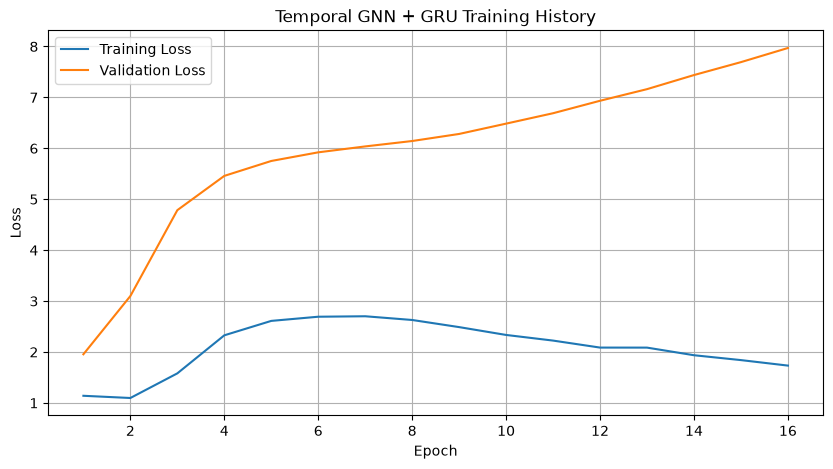

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Temporal GNN + GRU Training History")
plt.legend()
plt.grid(True)
plt.show()

In [143]:
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=DEVICE,
        weights_only=True
    )
)

model.to(DEVICE)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [144]:
def predict_dataset(
    model,
    dataset,
    device
):

    model.eval()

    probabilities = []
    actual_labels = []

    with torch.no_grad():

        for idx in range(len(dataset)):

            X_sequence = dataset.X_data[idx]
            edge_sequence = dataset.edge_data[idx]
            weight_sequence = dataset.weight_data[idx]

            graph_sequence, prepared_edges, prepared_weights = (
                prepare_graph_sequence(
                    X_sequence,
                    edge_sequence,
                    weight_sequence,
                    device
                )
            )

            logits = model(
                graph_sequence,
                prepared_edges,
                prepared_weights
            )

            probability = torch.sigmoid(
                logits
            ).item()

            probabilities.append(probability)

            actual_labels.append(
                int(dataset.y_data[idx])
            )

    return (
        np.asarray(actual_labels),
        np.asarray(probabilities)
    )


y_train_actual, train_probabilities = predict_dataset(
    model,
    train_dataset,
    DEVICE
)

y_val_actual, val_probabilities = predict_dataset(
    model,
    val_dataset,
    DEVICE
)

y_test_actual, test_probabilities = predict_dataset(
    model,
    test_dataset,
    DEVICE
)

print("Training predictions:", len(train_probabilities))
print("Validation predictions:", len(val_probabilities))
print("Test predictions:", len(test_probabilities))

Training predictions: 31
Validation predictions: 8
Test predictions: 8


In [145]:
def calculate_metrics(
    y_true,
    probabilities,
    threshold=0.5
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        )
    }

    if len(np.unique(y_true)) == 2:

        metrics["roc_auc"] = roc_auc_score(
            y_true,
            probabilities
        )

        metrics["pr_auc"] = average_precision_score(
            y_true,
            probabilities
        )

    else:

        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics


print("Metric function created.")

Metric function created.


In [146]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    metrics = calculate_metrics(
        y_val_actual,
        val_probabilities,
        threshold=round(float(threshold), 2)
    )

    threshold_results.append(metrics)

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.10,0.250,0.250000,1.0,0.400000,0.25,0.242857
1,0.15,0.250,0.250000,1.0,0.400000,0.25,0.242857
2,0.20,0.250,0.250000,1.0,0.400000,0.25,0.242857
3,0.25,0.250,0.250000,1.0,0.400000,0.25,0.242857
4,0.30,0.250,0.250000,1.0,0.400000,0.25,0.242857
5,0.35,0.375,0.285714,1.0,0.444444,0.25,0.242857
6,0.40,0.250,0.166667,0.5,0.250000,0.25,0.242857
7,0.45,0.750,0.000000,0.0,0.000000,0.25,0.242857
8,0.50,0.750,0.000000,0.0,0.000000,0.25,0.242857
9,0.55,0.750,0.000000,0.0,0.000000,0.25,0.242857


In [147]:
best_threshold_row = threshold_df.sort_values(
    by="f1",
    ascending=False
).iloc[0]

BEST_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print("Selected validation threshold:", BEST_THRESHOLD)
print("Validation F1:", best_threshold_row["f1"])
print("Validation precision:", best_threshold_row["precision"])
print("Validation recall:", best_threshold_row["recall"])

Selected validation threshold: 0.35
Validation F1: 0.4444444444444444
Validation precision: 0.2857142857142857
Validation recall: 1.0


In [148]:
test_metrics_default = calculate_metrics(
    y_test_actual,
    test_probabilities,
    threshold=0.5
)

test_metrics_selected = calculate_metrics(
    y_test_actual,
    test_probabilities,
    threshold=BEST_THRESHOLD
)

test_metrics_df = pd.DataFrame([
    {
        "evaluation": "Default threshold",
        **test_metrics_default
    },
    {
        "evaluation": "Validation-selected threshold",
        **test_metrics_selected
    }
])

display(test_metrics_df)

,evaluation,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Default threshold,0.50,1.0,0.0,0.0,0.0,NaN,NaN
1,Validation-selected threshold,0.35,0.0,0.0,0.0,0.0,NaN,NaN


In [149]:
test_predictions = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_test_actual,
        test_predictions,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_actual,
        test_predictions
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       8.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       8.0
   macro avg       0.00      0.00      0.00       8.0
weighted avg       0.00      0.00      0.00       8.0

Confusion Matrix:
[[0 8]
 [0 0]]


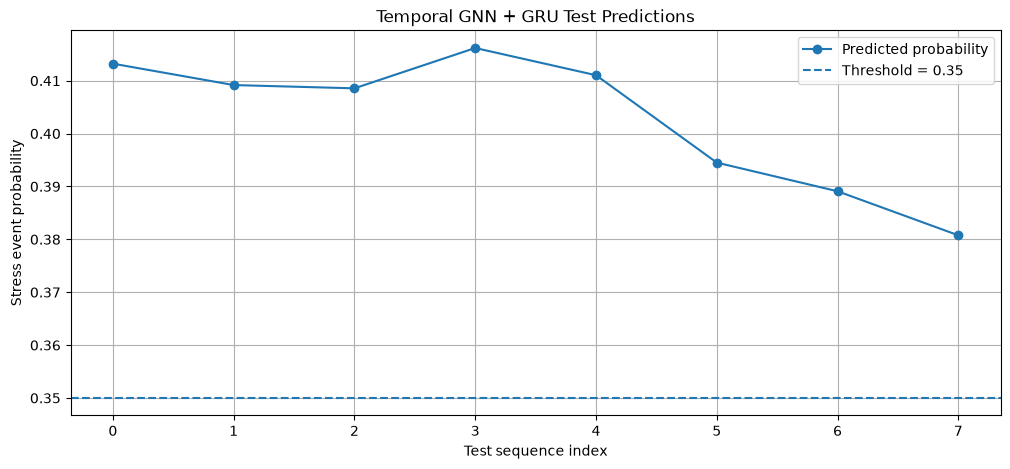

In [150]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(test_probabilities)),
    test_probabilities,
    marker="o",
    label="Predicted probability"
)

plt.axhline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Threshold = {BEST_THRESHOLD:.2f}"
)

plt.xlabel("Test sequence index")
plt.ylabel("Stress event probability")
plt.title("Temporal GNN + GRU Test Predictions")
plt.legend()
plt.grid(True)
plt.show()

In [151]:
gnn_results_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_test_metrics.csv"
)

test_metrics_df.to_csv(
    gnn_results_path,
    index=False
)

threshold_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_threshold_analysis.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False
)

print("Saved test metrics:")
print(gnn_results_path)

print("\nSaved threshold analysis:")
print(threshold_path)

Saved test metrics:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_test_metrics.csv

Saved threshold analysis:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_threshold_analysis.csv


In [152]:
import json

gnn_metadata = {
    "model": "Custom Weighted Temporal GNN + GRU",
    "sequence_length": SEQUENCE_LENGTH,
    "input_dimension": int(input_dim),
    "hidden_dimension": 32,
    "gru_dimension": 32,
    "dropout": 0.2,
    "epochs_configured": EPOCHS,
    "best_epoch": int(best_epoch),
    "best_validation_loss": float(best_val_loss),
    "selected_threshold": float(BEST_THRESHOLD),
    "total_aligned_graphs": int(len(X_aligned)),
    "training_sequences": int(len(X_train_seq)),
    "validation_sequences": int(len(X_val_seq)),
    "test_sequences": int(len(X_test_seq)),
    "class_distribution": {
        "class_0": int(np.sum(y_aligned == 0)),
        "class_1": int(np.sum(y_aligned == 1))
    }
}

metadata_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_metadata.json"
)

with open(metadata_path, "w") as file:

    json.dump(
        gnn_metadata,
        file,
        indent=4
    )

print("Metadata saved to:")
print(metadata_path)

Metadata saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_metadata.json


In [153]:
print("=" * 60)
print("TEMPORAL GNN + GRU EXPERIMENT SUMMARY")
print("=" * 60)

print("Aligned graph snapshots:", len(X_aligned))
print("Number of nodes:", X_aligned.shape[1])
print("Node feature dimension:", X_aligned.shape[2])
print("Sequence length:", SEQUENCE_LENGTH)

print("\nSequence counts:")
print("Train:", len(X_train_seq))
print("Validation:", len(X_val_seq))
print("Test:", len(X_test_seq))

print("\nTraining:")
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 6))

print("\nEvaluation:")
print("Selected threshold:", BEST_THRESHOLD)

print("\nTest metrics:")
display(test_metrics_df)

print("\nOutput directory:")
print(OUTPUT_DIR)

TEMPORAL GNN + GRU EXPERIMENT SUMMARY
Aligned graph snapshots: 59
Number of nodes: 10
Node feature dimension: 10
Sequence length: 5

Sequence counts:
Train: 31
Validation: 8
Test: 8

Training:
Best epoch: 1
Best validation loss: 1.95502

Evaluation:
Selected threshold: 0.35

Test metrics:


,evaluation,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Default threshold,0.50,1.0,0.0,0.0,0.0,NaN,NaN
1,Validation-selected threshold,0.35,0.0,0.0,0.0,0.0,NaN,NaN



Output directory:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible


In [154]:
from pathlib import Path

expected_outputs = [
    "temporal_gnn_gru_best_model.pt",
    "temporal_gnn_gru_training_history.csv",
    "temporal_gnn_gru_test_metrics.csv",
    "temporal_gnn_gru_threshold_analysis.csv",
    "temporal_gnn_gru_metadata.json"
]

print("Output verification:")
print("-" * 60)

for filename in expected_outputs:

    file_path = OUTPUT_DIR / filename

    print(
        f"{filename}: "
        f"{'EXISTS' if file_path.exists() else 'MISSING'}"
    )

Output verification:
------------------------------------------------------------
temporal_gnn_gru_best_model.pt: EXISTS
temporal_gnn_gru_training_history.csv: EXISTS
temporal_gnn_gru_test_metrics.csv: EXISTS
temporal_gnn_gru_threshold_analysis.csv: EXISTS
temporal_gnn_gru_metadata.json: EXISTS


In [155]:
test_prediction_df = pd.DataFrame({
    "actual_label": y_test_actual,
    "predicted_probability": test_probabilities,
    "predicted_label_default": (
        test_probabilities >= 0.5
    ).astype(int),
    "predicted_label_selected": (
        test_probabilities >= BEST_THRESHOLD
    ).astype(int)
})

test_predictions_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_test_predictions.csv"
)

test_prediction_df.to_csv(
    test_predictions_path,
    index=False
)

display(test_prediction_df)

print("Test predictions saved to:")
print(test_predictions_path)

,actual_label,predicted_probability,predicted_label_default,predicted_label_selected
0,0,0.413221,0,1
1,0,0.409174,0,1
2,0,0.408555,0,1
3,0,0.416181,0,1
4,0,0.411036,0,1
5,0,0.394511,0,1
6,0,0.389090,0,1
7,0,0.380762,0,1


Test predictions saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_test_predictions.csv


In [156]:
majority_class = int(
    np.bincount(y_train_seq).argmax()
)

baseline_predictions = np.full(
    len(y_test_actual),
    majority_class
)

baseline_metrics = {
    "model": "Majority Class Baseline",
    "accuracy": accuracy_score(
        y_test_actual,
        baseline_predictions
    ),
    "precision": precision_score(
        y_test_actual,
        baseline_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test_actual,
        baseline_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test_actual,
        baseline_predictions,
        zero_division=0
    )
}

gnn_metrics = calculate_metrics(
    y_test_actual,
    test_probabilities,
    threshold=BEST_THRESHOLD
)

gnn_comparison = {
    "model": "Temporal GNN + GRU",
    "accuracy": gnn_metrics["accuracy"],
    "precision": gnn_metrics["precision"],
    "recall": gnn_metrics["recall"],
    "f1": gnn_metrics["f1"]
}

comparison_df = pd.DataFrame([
    baseline_metrics,
    gnn_comparison
])

display(comparison_df)

,model,accuracy,precision,recall,f1
0,Majority Class Baseline,1.0,0.0,0.0,0.0
1,Temporal GNN + GRU,0.0,0.0,0.0,0.0


In [157]:
print("Actual test class distribution:")
print(
    pd.Series(y_test_actual)
    .value_counts()
    .sort_index()
)

print("\nPredicted test class distribution:")
print(
    pd.Series(
        (test_probabilities >= BEST_THRESHOLD).astype(int)
    )
    .value_counts()
    .sort_index()
)

print("\nPredicted probability statistics:")
print(
    pd.Series(test_probabilities)
    .describe()
)

Actual test class distribution:
0    8
Name: count, dtype: int64

Predicted test class distribution:
1    8
Name: count, dtype: int64

Predicted probability statistics:
count    8.000000
mean     0.402816
std      0.012937
min      0.380762
25%      0.393156
50%      0.408865
75%      0.411582
max      0.416181
dtype: float64


In [158]:
if len(np.unique(y_test_actual)) == 2:

    test_pr_auc = average_precision_score(
        y_test_actual,
        test_probabilities
    )

    test_roc_auc = roc_auc_score(
        y_test_actual,
        test_probabilities
    )

    print("Test PR-AUC:", round(test_pr_auc, 4))
    print("Test ROC-AUC:", round(test_roc_auc, 4))

else:

    print(
        "Test set contains only one class."
    )

    print(
        "ROC-AUC and PR-AUC cannot be reliably calculated."
    )

Test set contains only one class.
ROC-AUC and PR-AUC cannot be reliably calculated.


In [159]:
comparison_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_baseline_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("Baseline comparison saved to:")
print(comparison_path)

Baseline comparison saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_baseline_comparison.csv


In [160]:
final_train_loss = history_df["train_loss"].iloc[-1]
final_val_loss = history_df["val_loss"].iloc[-1]

loss_difference = (
    final_val_loss - final_train_loss
)

print("Final training loss:", round(final_train_loss, 6))
print("Final validation loss:", round(final_val_loss, 6))
print("Validation minus training loss:", round(loss_difference, 6))

if loss_difference > 0:
    print(
        "\nValidation loss is higher than training loss."
    )
    print(
        "This may indicate overfitting, but the small dataset "
        "makes the conclusion uncertain."
    )
else:
    print(
        "\nValidation loss is not higher than training loss."
    )

Final training loss: 1.732824
Final validation loss: 7.970441
Validation minus training loss: 6.237617

Validation loss is higher than training loss.
This may indicate overfitting, but the small dataset makes the conclusion uncertain.


In [161]:
research_summary = {
    "experiment_name": "Temporal GNN + GRU",
    "graph_type": "Reconstructed rolling correlation graph",
    "graph_snapshots": int(len(X_aligned)),
    "nodes_per_graph": int(X_aligned.shape[1]),
    "node_features": int(X_aligned.shape[2]),
    "sequence_length": int(SEQUENCE_LENGTH),
    "train_sequences": int(len(X_train_seq)),
    "validation_sequences": int(len(X_val_seq)),
    "test_sequences": int(len(X_test_seq)),
    "total_class_0": int(np.sum(y_aligned == 0)),
    "total_class_1": int(np.sum(y_aligned == 1)),
    "best_epoch": int(best_epoch),
    "selected_threshold": float(BEST_THRESHOLD),
    "test_f1": float(gnn_metrics["f1"]),
    "test_precision": float(gnn_metrics["precision"]),
    "test_recall": float(gnn_metrics["recall"]),
    "test_accuracy": float(gnn_metrics["accuracy"])
}

summary_path = (
    OUTPUT_DIR /
    "temporal_gnn_gru_research_summary.json"
)

with open(summary_path, "w") as file:

    json.dump(
        research_summary,
        file,
        indent=4
    )

print("Research summary saved to:")
print(summary_path)

display(pd.DataFrame([research_summary]))

Research summary saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_gnn_gru_research_summary.json


,experiment_name,graph_type,graph_snapshots,nodes_per_graph,node_features,sequence_length,train_sequences,validation_sequences,test_sequences,total_class_0,total_class_1,best_epoch,selected_threshold,test_f1,test_precision,test_recall,test_accuracy
0,Temporal GNN + GRU,Reconstructed rolling correlation graph,59,10,10,5,31,8,8,52,7,1,0.35,0.0,0.0,0.0,0.0


In [162]:
checklist = {
    "Graph snapshots aligned": len(X_aligned) > 0,
    "Node features available": X_aligned.shape[2] > 0,
    "Edge snapshots aligned": len(aligned_edge_indices) == len(X_aligned),
    "Labels aligned": len(y_aligned) == len(X_aligned),
    "Model checkpoint exists": best_model_path.exists(),
    "Training history exists": history_path.exists(),
    "Test metrics exists": gnn_results_path.exists(),
    "Test predictions exists": test_predictions_path.exists(),
    "Research summary exists": summary_path.exists()
}

checklist_df = pd.DataFrame(
    list(checklist.items()),
    columns=["Check", "Passed"]
)

display(checklist_df)

if checklist_df["Passed"].all():
    print("All experiment checks passed.")
else:
    print("Some checks failed. Review the output above.")

,Check,Passed
0,Graph snapshots aligned,True
1,Node features available,True
2,Edge snapshots aligned,True
3,Labels aligned,True
4,Model checkpoint exists,True
5,Training history exists,True
6,Test metrics exists,True
7,Test predictions exists,True
8,Research summary exists,True


All experiment checks passed.


In [163]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

PHASE14_DIR = PROJECT_ROOT / "data" / "results" / "phase14"

PHASE14_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Phase 14 directory:")
print(PHASE14_DIR)

Phase 14 directory:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14


In [164]:
experiment_registry = {
    "project": "FinGraph-Sentinel",
    "phase": "Phase 14",
    "objective": (
        "Research validation and multi-signal systemic "
        "risk early warning development"
    ),
    "data_source": (
        "Historical financial time series and reconstructed "
        "rolling correlation graphs"
    ),
    "models_completed": [
        "Temporal GRU baseline",
        "Custom weighted Temporal GNN + GRU"
    ],
    "graph_reconstruction": {
        "window_size": 60,
        "correlation_threshold": 0.5,
        "matched_edge_count_dates": 60
    },
    "research_focus": [
        "Multi-signal risk integration",
        "Early warning detection",
        "Temporal robustness",
        "Model comparison"
    ],
    "limitations": [
        "Small number of positive events",
        "Reconstructed correlation graph",
        "Potential instability from class imbalance"
    ]
}

registry_path = (
    PHASE14_DIR /
    "phase14_experiment_registry.json"
)

with open(registry_path, "w") as file:
    json.dump(
        experiment_registry,
        file,
        indent=4
    )

print("Experiment registry saved:")
print(registry_path)

Experiment registry saved:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\phase14_experiment_registry.json


In [165]:
SYSTEMIC_RISK_PATH = (
    PROJECT_ROOT /
    "data" /
    "results" /
    "dynamic_systemic_risk.csv"
)

systemic_risk_df = pd.read_csv(
    SYSTEMIC_RISK_PATH
)

systemic_risk_df["date"] = pd.to_datetime(
    systemic_risk_df["date"]
).dt.normalize()

print("Shape:", systemic_risk_df.shape)
print("Columns:", systemic_risk_df.columns.tolist())

display(systemic_risk_df.head())

Shape: (1200, 6)
Columns: ['date', 'company', 'degree', 'betweenness', 'pagerank', 'systemic_risk_score']


,date,company,degree,betweenness,pagerank,systemic_risk_score
0,2021-11-12,AAPL,0.333333,0.000000,0.137777,0.155111
1,2021-11-12,AMZN,0.333333,0.027778,0.140320,0.164461
2,2021-11-12,GOOGL,0.333333,0.027778,0.153270,0.169641
3,2021-11-12,JPM,0.000000,0.000000,0.020134,0.008054
4,2021-11-12,MA,0.111111,0.000000,0.134228,0.087025


In [166]:
EWS_PATH = (
    PROJECT_ROOT /
    "data" /
    "results" /
    "ews.csv"
)

if EWS_PATH.exists():

    ews_df = pd.read_csv(EWS_PATH)

    if "date" in ews_df.columns:
        ews_df["date"] = pd.to_datetime(
            ews_df["date"]
        ).dt.normalize()

    print("EWS shape:", ews_df.shape)
    print("EWS columns:", ews_df.columns.tolist())

    display(ews_df.head())

else:

    ews_df = None

    print(
        "EWS file was not found at:"
    )

    print(EWS_PATH)

EWS file was not found at:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\ews.csv


In [167]:
print("Systemic-risk data types:")
display(
    systemic_risk_df.dtypes.to_frame(
        name="dtype"
    )
)

print("\nMissing values:")
display(
    systemic_risk_df.isna().sum()
)

print("\nSummary statistics:")
display(
    systemic_risk_df.describe(
        include="all"
    ).T
)

Systemic-risk data types:


,dtype
date,datetime64[us]
company,str
degree,float64
betweenness,float64
pagerank,float64
systemic_risk_score,float64



Missing values:


date                   0
company                0
degree                 0
betweenness            0
pagerank               0
systemic_risk_score    0
dtype: int64


Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1200,NaN,NaN,NaN,2024-03-28 18:48:00,2021-11-12 00:00:00,2023-01-21 06:00:00,2024-03-28 12:00:00,2025-06-06 12:00:00,2026-08-13 00:00:00,NaN
company,1200,10,AAPL,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
degree,1200.0,NaN,NaN,NaN,0.362222,0.0,0.111111,0.222222,0.555556,1.0,0.347399
betweenness,1200.0,NaN,NaN,NaN,0.025602,0.0,0.0,0.0,0.0,0.694444,0.070852
pagerank,1200.0,NaN,NaN,NaN,0.1,0.016393,0.056299,0.104412,0.133632,0.312496,0.055215
systemic_risk_score,1200.0,NaN,NaN,NaN,0.156347,0.006557,0.059514,0.120724,0.262557,0.567819,0.121475


In [168]:
# Create a working copy
risk_signals_df = systemic_risk_df.copy()

# Ensure date is normalized
risk_signals_df["date"] = pd.to_datetime(
    risk_signals_df["date"]
).dt.normalize()

# Identify numeric columns
numeric_columns = risk_signals_df.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Available numeric signals:")
for column in numeric_columns:
    print("-", column)

assert len(numeric_columns) > 0, (
    "No numeric risk signals found."
)

Available numeric signals:
- degree
- betweenness
- pagerank
- systemic_risk_score


In [169]:
signal_summary = risk_signals_df[
    numeric_columns
].describe().T

signal_summary["missing_values"] = (
    risk_signals_df[numeric_columns].isna().sum()
)

signal_summary["unique_values"] = (
    risk_signals_df[numeric_columns].nunique()
)

display(signal_summary)

,count,mean,std,min,25%,50%,75%,max,missing_values,unique_values
degree,1200.0,0.362222,0.347399,0.000000,0.111111,0.222222,0.555556,1.000000,0,10
betweenness,1200.0,0.025602,0.070852,0.000000,0.000000,0.000000,0.000000,0.694444,0,21
pagerank,1200.0,0.100000,0.055215,0.016393,0.056299,0.104412,0.133632,0.312496,0,856
systemic_risk_score,1200.0,0.156347,0.121475,0.006557,0.059514,0.120724,0.262557,0.567819,0,850


In [170]:
usable_signals = []

for column in numeric_columns:

    series = risk_signals_df[column]

    # Exclude columns with all missing values
    if series.notna().sum() == 0:
        continue

    # Exclude constant columns
    if series.nunique(dropna=True) <= 1:
        continue

    usable_signals.append(column)

print("Usable signals:")
for column in usable_signals:
    print("-", column)

assert len(usable_signals) > 0, (
    "No usable numeric signals remain."
)

Usable signals:
- degree
- betweenness
- pagerank
- systemic_risk_score


In [171]:
risk_signals_df[usable_signals] = (
    risk_signals_df[usable_signals]
    .replace([np.inf, -np.inf], np.nan)
)

risk_signals_df[usable_signals] = (
    risk_signals_df[usable_signals]
    .interpolate(
        method="linear",
        limit_direction="both"
    )
)

risk_signals_df[usable_signals] = (
    risk_signals_df[usable_signals]
    .fillna(0)
)

print("Remaining missing values:")
display(
    risk_signals_df[usable_signals].isna().sum()
)

Remaining missing values:


degree                 0
betweenness            0
pagerank               0
systemic_risk_score    0
dtype: int64

In [172]:
normalized_signals_df = risk_signals_df[
    ["date"] + usable_signals
].copy()

for column in usable_signals:

    normalized_signals_df[column] = (
        normalized_signals_df[column]
        .rank(
            method="average",
            pct=True
        )
    )

display(
    normalized_signals_df.head()
)

,date,degree,betweenness,pagerank,systemic_risk_score
0,2021-11-12,0.585833,0.392917,0.795833,0.566667
1,2021-11-12,0.585833,0.817917,0.809167,0.596667
2,2021-11-12,0.585833,0.817917,0.868333,0.605000
3,2021-11-12,0.109583,0.392917,0.070833,0.070833
4,2021-11-12,0.315000,0.392917,0.775417,0.342083


In [173]:
normalized_signals_df["multi_signal_risk_score"] = (
    normalized_signals_df[usable_signals]
    .mean(axis=1)
)

print("Multi-signal score statistics:")
display(
    normalized_signals_df[
        "multi_signal_risk_score"
    ].describe()
)

display(
    normalized_signals_df.head()
)

Multi-signal score statistics:


count    1200.000000
mean        0.500417
std         0.222402
min         0.128958
25%         0.307083
50%         0.523438
75%         0.675104
max         0.958958
Name: multi_signal_risk_score, dtype: float64

,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score
0,2021-11-12,0.585833,0.392917,0.795833,0.566667,0.585312
1,2021-11-12,0.585833,0.817917,0.809167,0.596667,0.702396
2,2021-11-12,0.585833,0.817917,0.868333,0.605000,0.719271
3,2021-11-12,0.109583,0.392917,0.070833,0.070833,0.161042
4,2021-11-12,0.315000,0.392917,0.775417,0.342083,0.456354


In [174]:
normalized_signals_df["risk_percentile"] = (
    normalized_signals_df[
        "multi_signal_risk_score"
    ]
    .rank(
        method="average",
        pct=True
    )
    * 100
)

print("Risk percentile distribution:")
display(
    normalized_signals_df[
        ["date", "multi_signal_risk_score", "risk_percentile"]
    ].head()
)

Risk percentile distribution:


,date,multi_signal_risk_score,risk_percentile
0,2021-11-12,0.585312,62.250000
1,2021-11-12,0.702396,80.916667
2,2021-11-12,0.719271,82.416667
3,2021-11-12,0.161042,7.083333
4,2021-11-12,0.456354,39.875000


In [175]:
def assign_risk_category(percentile):

    if percentile >= 90:
        return "Very High"

    elif percentile >= 75:
        return "High"

    elif percentile >= 50:
        return "Moderate"

    else:
        return "Lower"


normalized_signals_df["exploratory_risk_category"] = (
    normalized_signals_df[
        "risk_percentile"
    ].apply(assign_risk_category)
)

display(
    normalized_signals_df[
        [
            "date",
            "multi_signal_risk_score",
            "risk_percentile",
            "exploratory_risk_category"
        ]
    ].head()
)

,date,multi_signal_risk_score,risk_percentile,exploratory_risk_category
0,2021-11-12,0.585312,62.250000,Moderate
1,2021-11-12,0.702396,80.916667,High
2,2021-11-12,0.719271,82.416667,High
3,2021-11-12,0.161042,7.083333,Lower
4,2021-11-12,0.456354,39.875000,Lower


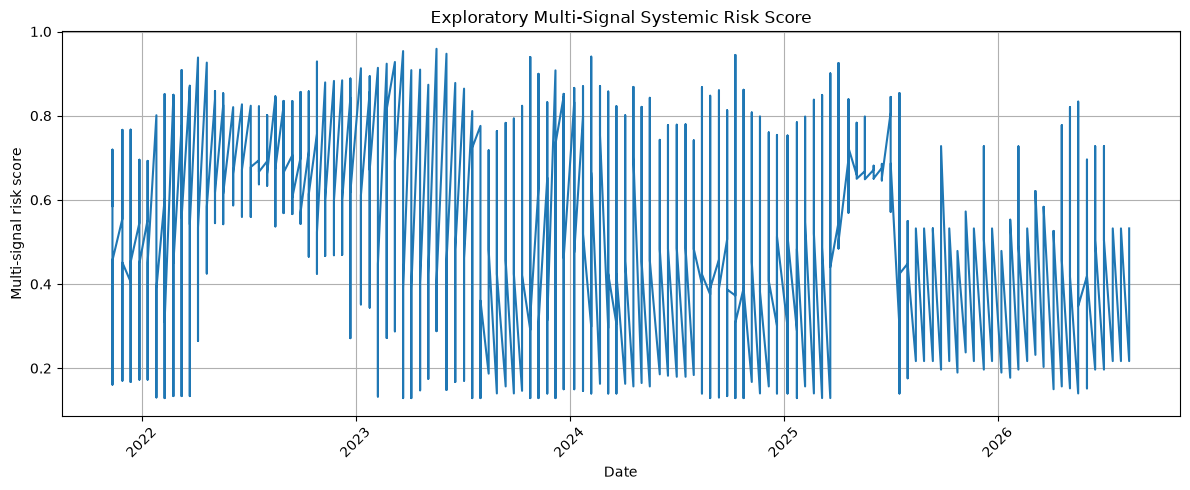

In [176]:
plt.figure(figsize=(12, 5))

plt.plot(
    normalized_signals_df["date"],
    normalized_signals_df["multi_signal_risk_score"]
)

plt.xlabel("Date")
plt.ylabel("Multi-signal risk score")
plt.title("Exploratory Multi-Signal Systemic Risk Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [177]:
MULTI_SIGNAL_PATH = (
    PHASE14_DIR /
    "multi_signal_systemic_risk_score.csv"
)

normalized_signals_df.to_csv(
    MULTI_SIGNAL_PATH,
    index=False
)

print("Saved multi-signal risk results:")
print(MULTI_SIGNAL_PATH)

Saved multi-signal risk results:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_systemic_risk_score.csv


In [178]:
signal_configuration = {
    "signals_used": usable_signals,
    "normalization": "Percentile rank",
    "aggregation": "Arithmetic mean",
    "risk_categories": {
        "Very High": "90th percentile and above",
        "High": "75th to below 90th percentile",
        "Moderate": "50th to below 75th percentile",
        "Lower": "Below 50th percentile"
    },
    "interpretation": (
        "Exploratory score requiring validation against "
        "future stress events"
    )
}

signal_configuration_path = (
    PHASE14_DIR /
    "multi_signal_configuration.json"
)

with open(signal_configuration_path, "w") as file:

    json.dump(
        signal_configuration,
        file,
        indent=4
    )

print("Signal configuration saved:")
print(signal_configuration_path)

Signal configuration saved:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_configuration.json


In [179]:
# Load the expanded temporal dataset
phase13_dataset = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "results"
    / "phase13"
    / "phase13_expanded_temporal_dataset.csv"
)

phase13_dataset["date"] = pd.to_datetime(
    phase13_dataset["date"]
).dt.normalize()

# Keep one target label per date
target_labels_df = (
    phase13_dataset[
        ["date", "future_stress_event"]
    ]
    .drop_duplicates("date")
    .sort_values("date")
    .reset_index(drop=True)
)

target_labels_df["future_stress_event"] = (
    pd.to_numeric(
        target_labels_df["future_stress_event"],
        errors="coerce"
    )
)

print("Target shape:", target_labels_df.shape)
print("Target date range:")
print(
    target_labels_df["date"].min(),
    "to",
    target_labels_df["date"].max()
)

display(target_labels_df.head())

Target shape: (1175, 2)
Target date range:
2021-11-12 00:00:00 to 2026-07-22 00:00:00


,date,future_stress_event
0,2021-11-12,0
1,2021-11-15,0
2,2021-11-16,0
3,2021-11-17,0
4,2021-11-18,0


In [180]:
validation_df = pd.merge(
    normalized_signals_df,
    target_labels_df,
    on="date",
    how="inner"
)

validation_df = (
    validation_df
    .dropna(subset=["future_stress_event"])
    .sort_values("date")
    .reset_index(drop=True)
)

validation_df["future_stress_event"] = (
    validation_df["future_stress_event"].astype(int)
)

print("Aligned validation rows:", len(validation_df))

print("\nClass distribution:")
print(
    validation_df["future_stress_event"]
    .value_counts()
    .sort_index()
)

display(validation_df.head())

Aligned validation rows: 1180

Class distribution:
future_stress_event
0    1020
1     160
Name: count, dtype: int64


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,exploratory_risk_category,future_stress_event
0,2021-11-12,0.585833,0.392917,0.795833,0.566667,0.585312,62.250000,Moderate,0
1,2021-11-12,0.585833,0.817917,0.809167,0.596667,0.702396,80.916667,High,0
2,2021-11-12,0.585833,0.817917,0.868333,0.605000,0.719271,82.416667,High,0
3,2021-11-12,0.109583,0.392917,0.070833,0.070833,0.161042,7.083333,Lower,0
4,2021-11-12,0.315000,0.392917,0.775417,0.342083,0.456354,39.875000,Lower,0


In [181]:
validation_classes = (
    validation_df["future_stress_event"]
    .nunique()
)

print("Number of target classes:", validation_classes)

if validation_classes < 2:
    print(
        "Only one target class is present. "
        "Classification metrics cannot be calculated reliably."
    )
else:
    print("Both target classes are present.")

Number of target classes: 2
Both target classes are present.


In [182]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

y_validation = validation_df[
    "future_stress_event"
].to_numpy()

risk_scores = validation_df[
    "multi_signal_risk_score"
].to_numpy()

if len(np.unique(y_validation)) == 2:

    risk_roc_auc = roc_auc_score(
        y_validation,
        risk_scores
    )

    risk_pr_auc = average_precision_score(
        y_validation,
        risk_scores
    )

    print("Multi-signal risk ROC-AUC:", round(risk_roc_auc, 4))
    print("Multi-signal risk PR-AUC:", round(risk_pr_auc, 4))

else:

    risk_roc_auc = np.nan
    risk_pr_auc = np.nan

    print("ROC-AUC and PR-AUC are unavailable.")

Multi-signal risk ROC-AUC: 0.646
Multi-signal risk PR-AUC: 0.1993


In [183]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

alert_results = []

for percentile_threshold in [75, 80, 85, 90, 95]:

    alerts = (
        validation_df["risk_percentile"]
        >= percentile_threshold
    ).astype(int)

    alert_results.append({
        "percentile_threshold": percentile_threshold,
        "alert_count": int(alerts.sum()),
        "actual_events": int(y_validation.sum()),
        "precision": precision_score(
            y_validation,
            alerts,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            alerts,
            zero_division=0
        ),
        "f1": f1_score(
            y_validation,
            alerts,
            zero_division=0
        )
    })

alert_results_df = pd.DataFrame(alert_results)

display(alert_results_df)

,percentile_threshold,alert_count,actual_events,precision,recall,f1
0,75,301,160,0.209302,0.39375,0.273319
1,80,240,160,0.204167,0.30625,0.245000
2,85,181,160,0.198895,0.22500,0.211144
3,90,121,160,0.239669,0.18125,0.206406
4,95,61,160,0.213115,0.08125,0.117647


In [184]:
risk_validation_path = (
    PHASE14_DIR /
    "multi_signal_risk_validation.csv"
)

alert_results_path = (
    PHASE14_DIR /
    "multi_signal_alert_threshold_results.csv"
)

validation_df.to_csv(
    risk_validation_path,
    index=False
)

alert_results_df.to_csv(
    alert_results_path,
    index=False
)

print("Saved validation dataset:")
print(risk_validation_path)

print("\nSaved alert results:")
print(alert_results_path)

Saved validation dataset:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_risk_validation.csv

Saved alert results:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_alert_threshold_results.csv


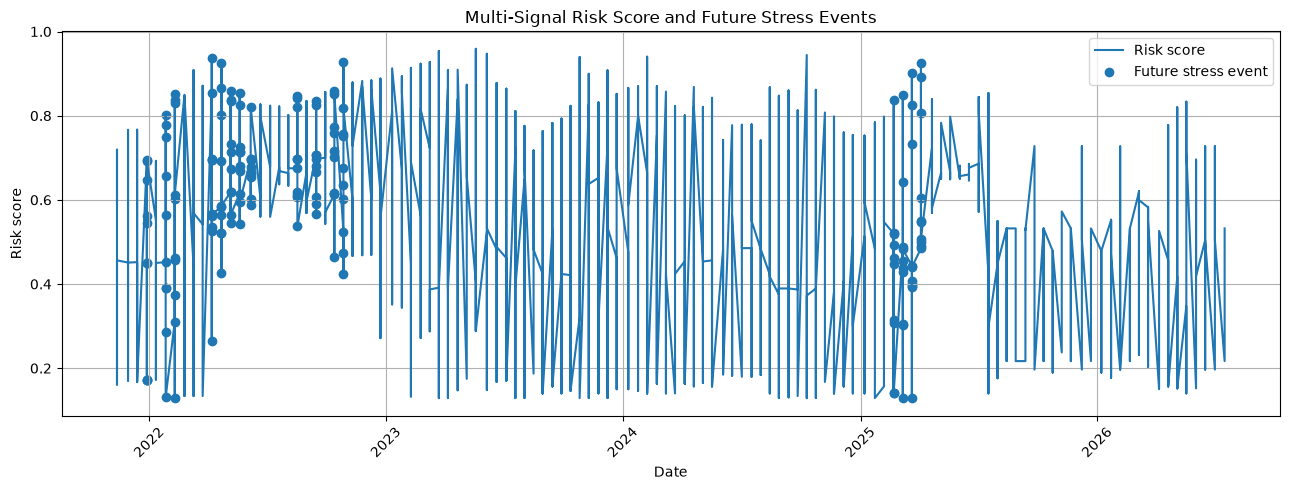

In [185]:
plt.figure(figsize=(13, 5))

plt.plot(
    validation_df["date"],
    validation_df["multi_signal_risk_score"],
    label="Risk score"
)

event_dates = validation_df.loc[
    validation_df["future_stress_event"] == 1,
    "date"
]

event_scores = validation_df.loc[
    validation_df["future_stress_event"] == 1,
    "multi_signal_risk_score"
]

plt.scatter(
    event_dates,
    event_scores,
    label="Future stress event"
)

plt.xlabel("Date")
plt.ylabel("Risk score")
plt.title(
    "Multi-Signal Risk Score and Future Stress Events"
)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()